In [1]:
!rm -rf /content/ML-BIO-TECH

In [2]:
# REPOSITORY SETUP
# Clones the public ML-BIO-TECH repo (code + data) into the Colab
# session so this analysis notebook can use the same modules and
# pre-built dataset as the rest of the pipeline, without depending
# on Google Drive.

import os
import subprocess

REPO_URL = "https://github.com/adrianyadila/ML-BIO-TECH.git"
REPO_DIR = "/content/ML-BIO-TECH"

if not os.path.exists(REPO_DIR):
    subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)

# Analysis & Interpretability — Next Steps
**Objectives:**
1. Dataset visualization & correlation analysis
2. Feature interpretability (SHAP, permutation importance)
3. Unsupervised learning for novel pattern discovery
4. KO-level differential analysis

In [3]:
!pip install openpyxl

In [4]:
!pip install rdkit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 17.8 MB/s eta 0:00:00


In [5]:
# === SETUP ===
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from IPython.display import display, HTML

# Style
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})
sns.set_style('whitegrid')

# Paths
PROJECT_ROOT = Path(REPO_DIR)
MODEL_DIR = PROJECT_ROOT / 'model'
MODEL_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(MODEL_DIR))

EC_ROOT = str(PROJECT_ROOT / 'data/parquet_output_samples/Annotation_Enzyme_Commission')
KO_ROOT = str(PROJECT_ROOT / 'data/parquet_output_samples/Annotation_KEGG_Orthology')
GCMS_ROOT = str(PROJECT_ROOT / 'data/parquet_output_samples/GC_MS_Metabolomics_Results')
KO_PATHWAY_MAPPING = str(MODEL_DIR / 'ko_to_kegg_pathway.tsv')

FIGDIR = str(MODEL_DIR / 'figures')
os.makedirs(FIGDIR, exist_ok=True)

print('Setup complete.')

Setup complete.


In [6]:
# === LOAD DATASET (EC + KO + KEGG) ===
# build_final_dataset expects nmdc_bsm dirs directly under ko_root,
# but our layout has a study-level dir in between.
# So we iterate per study and concat, same as build_kegg_only_dataset.

from ec_processing import build_ec_feature_matrix
from ko_processing import build_ko_feature_matrix, build_ko_long_table
from kegg_pathway_processing import build_kegg_pathway_feature_matrix
from gcms_processing import build_gcms_targets

all_datasets = []

studies = [
    d for d in os.listdir(KO_ROOT)
    if d.startswith('sty-')
    and os.path.isdir(os.path.join(KO_ROOT, d))
]

for study in sorted(studies):
    print(f'\nProcessing study: {study}')

    ec_study  = os.path.join(EC_ROOT, study)
    ko_study  = os.path.join(KO_ROOT, study)
    gcms_study = os.path.join(GCMS_ROOT, study)

    # Skip if any modality is missing for this study
    missing = []
    if not os.path.exists(ec_study):   missing.append('EC')
    if not os.path.exists(ko_study):   missing.append('KO')
    if not os.path.exists(gcms_study): missing.append('GCMS')
    if missing:
        print(f'  Skipping — missing: {missing}')
        continue

    try:
        # EC features
        X_ec = build_ec_feature_matrix(ec_study)
        # KO features
        X_ko = build_ko_feature_matrix(ko_study)
        # KEGG pathway features
        ko_long = build_ko_long_table(ko_study)
        X_kegg = build_kegg_pathway_feature_matrix(ko_long, KO_PATHWAY_MAPPING)
        # Targets
        y = build_gcms_targets(gcms_study, study_quantile=0.6)

        # Merge all
        X = (
            X_ec
            .merge(X_ko, on='biosample', how='inner')
            .merge(X_kegg, on='biosample', how='inner')
        )
        dataset = X.merge(y, on='biosample', how='inner')

        if not dataset.empty:
            dataset['study'] = study
            all_datasets.append(dataset)
            print(f'  OK — {len(dataset)} samples, {dataset.shape[1]} columns')

    except Exception as e:
        print(f'  Error: {e}')
        continue

df = (
    pd.concat(all_datasets, ignore_index=True)
      .drop_duplicates(subset='biosample')
      .reset_index(drop=True)
)
print(f'\nFinal dataset: {df.shape[0]} samples, {df.shape[1]} columns')


Processing study: sty-11-547rwq94

MES distribution (this study)
count    437.000000
mean       0.071250
std        0.057179
min        0.000000
25%        0.030822
50%        0.048755
75%        0.096685
max        0.321944
Name: MES, dtype: float64

Per-study quantile used : 0.6
Per-study threshold     : 0.063620

MES_label distribution (this study)
MES_label
0    262
1    175
Name: count, dtype: int64
Proportion positive     : 0.400
Biosamples with MES == 0: 3
  OK — 46 samples, 22 columns

Processing study: sty-11-8ws97026

MES distribution (this study)
count    22.000000
mean      0.011727
std       0.003344
min       0.006918
25%       0.009413
50%       0.011303
75%       0.013158
max       0.020011
Name: MES, dtype: float64

Per-study quantile used : 0.6
Per-study threshold     : 0.011807

MES_label distribution (this study)
MES_label
0    13
1     9
Name: count, dtype: int64
Proportion positive     : 0.409
Biosamples with MES == 0: 0
  OK — 16 samples, 22 columns

Processing 

In [7]:
# === SAVE DATASET TO EXCEL ===

import os

EXCEL_PATH = str(PROJECT_ROOT / 'model' / 'outputs' / 'final_dataset.xlsx')

os.makedirs(os.path.dirname(EXCEL_PATH), exist_ok=True)

df.to_excel(EXCEL_PATH, index=False)

print(f"Dataset saved: {EXCEL_PATH}")
print(f"Shape: {df.shape[0]} samples × {df.shape[1]} columns")

Dataset saved: /content/ML-BIO-TECH/model/outputs/final_dataset.xlsx
Shape: 95 samples × 22 columns


---
## 1. Dataset Overview

In [8]:
# === 1a. DATASET OVERVIEW TABLE ===

feature_cols = [
    c for c in df.columns
    if c not in ['biosample', 'study', 'MES', 'MES_label']
]

# Summary info
summary = pd.DataFrame({
    'Metric': [
        'Total samples (rows)',
        'Total columns',
        'Number of features',
        'Unique biosamples',
        'Unique studies',
        'Degraders (label=1)',
        'Non-degraders (label=0)',
        'Class ratio (1/0)',
    ],
    'Value': [
        df.shape[0],
        df.shape[1],
        len(feature_cols),
        df['biosample'].nunique(),
        df['study'].nunique() if 'study' in df.columns else 'N/A',
        int((df['MES_label'] == 1).sum()),
        int((df['MES_label'] == 0).sum()),
        f"{(df['MES_label'] == 1).sum() / max((df['MES_label'] == 0).sum(), 1):.2f}",
    ]
})

display(summary.style
    .set_caption('Dataset Summary')
    .set_properties(**{'text-align': 'left'})
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

Metric,Value
Total samples (rows),95
Total columns,22
Number of features,18
Unique biosamples,95
Unique studies,3
Degraders (label=1),26
Non-degraders (label=0),69
Class ratio (1/0),0.38


In [9]:
# === 1b. FEATURE LIST TABLE ===

def classify_feature(name):
    if name.startswith('total_ec') or name.startswith('unique_ec') or name.startswith('ec_level'):
        return 'EC (count)'
    elif name.startswith('total_ko') or name.startswith('unique_ko'):
        return 'KO (count)'
    elif name.endswith('_coverage'):
        return 'KEGG pathway (coverage)'
    elif name.endswith('_presence'):
        return 'KEGG pathway (presence)'
    elif name in ['aromatic_pathway_count', 'mean_aromatic_coverage']:
        return 'KEGG pathway (aggregate)'
    return 'Other'

feat_info = pd.DataFrame({
    'Feature': feature_cols,
    'Type': [classify_feature(f) for f in feature_cols],
    'Min': [df[f].min() for f in feature_cols],
    'Max': [df[f].max() for f in feature_cols],
    'Mean': [df[f].mean() for f in feature_cols],
    'Std': [df[f].std() for f in feature_cols],
    'Zeros (%)': [(df[f] == 0).mean() * 100 for f in feature_cols],
})

display(feat_info.style
    .set_caption('Feature Inventory')
    .format({'Min': '{:.3f}', 'Max': '{:.3f}', 'Mean': '{:.3f}', 'Std': '{:.3f}', 'Zeros (%)': '{:.1f}%'})
    .hide(axis='index')
    .background_gradient(subset=['Zeros (%)'], cmap='YlOrRd', vmin=0, vmax=100)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '4px 10px'), ('font-size', '11px')]},
    ])
)

Feature,Type,Min,Max,Mean,Std,Zeros (%)
total_ec_count,EC (count),0.000,493453.000,54169.263,81039.120,2.1%
unique_ec_count,EC (count),0.000,2896.000,1524.779,839.951,2.1%
ec_level1_count,EC (count),0.000,7.000,6.653,1.351,2.1%
ec_level2_count,EC (count),0.000,70.000,58.926,17.433,2.1%
ec_level3_count,EC (count),0.000,237.000,182.179,67.597,2.1%
total_ko_count,KO (count),1.000,908009.000,97690.726,153387.956,0.0%
unique_ko_count,KO (count),1.000,9888.000,3807.411,2531.395,0.0%
benzoate_degradation_coverage,KEGG pathway (coverage),0.000,0.698,0.389,0.225,6.3%
benzene_degradation_coverage,KEGG pathway (coverage),0.000,0.467,0.188,0.120,12.6%
toluene_degradation_coverage,KEGG pathway (coverage),0.000,0.500,0.185,0.141,12.6%


In [10]:
# === 1c. FIRST ROWS OF DATASET ===

display(df.head(10).style
    .set_caption('First 10 rows of the dataset')
    .format(precision=4)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '6px'), ('font-size', '9px')]},
        {'selector': 'td', 'props': [('padding', '4px 6px'), ('font-size', '9px')]},
    ])
    .background_gradient(subset=['MES'], cmap='RdYlGn', vmin=0, vmax=1)
)

,biosample,total_ec_count,unique_ec_count,ec_level1_count,ec_level2_count,ec_level3_count,total_ko_count,unique_ko_count,benzoate_degradation_coverage,benzene_degradation_coverage,toluene_degradation_coverage,xylene_degradation_coverage,ethylbenzene_degradation_coverage,pah_degradation_coverage,chlorobenzene_degradation_coverage,fluorobenzoate_degradation_coverage,nitrotoluene_degradation_coverage,anaerobic_aromatic_degradation_coverage,mean_aromatic_coverage,MES,MES_label,study
0,nmdc_bsm-11-06pa9m89,3,3,2,3,3,5,5,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0266,0,sty-11-547rwq94
1,nmdc_bsm-11-1302r041,14479,1537,7,65,205,23960,3302,0.4741,0.2333,0.1087,0.3736,0.0625,0.2093,0.2439,0.3889,0.3043,0.2941,0.2693,0.0583,0,sty-11-547rwq94
2,nmdc_bsm-11-2ah5z651,46,41,5,17,27,78,73,0.0086,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0294,0.0038,0.0217,0,sty-11-547rwq94
3,nmdc_bsm-11-2hv7wn93,34744,1866,7,67,216,55996,4199,0.4828,0.1667,0.2391,0.3846,0.0625,0.2558,0.2927,0.3889,0.3478,0.3235,0.2944,0.0364,0,sty-11-547rwq94
4,nmdc_bsm-11-30npyx54,54,51,7,28,38,97,92,0.0086,0.0000,0.0000,0.0000,0.0000,0.0000,0.0244,0.0000,0.0000,0.0000,0.0033,0.0379,0,sty-11-547rwq94
5,nmdc_bsm-11-39qcw250,4501,1083,7,64,184,7858,2123,0.2500,0.1000,0.0652,0.0989,0.0625,0.0233,0.1707,0.1111,0.1304,0.1765,0.1189,0.0446,0,sty-11-547rwq94
6,nmdc_bsm-11-3h3w1c57,2647,917,7,60,164,4444,1844,0.1207,0.1000,0.0435,0.0549,0.0625,0.0000,0.1220,0.1111,0.0435,0.0588,0.0717,0.0383,0,sty-11-547rwq94
7,nmdc_bsm-11-407zcq77,708,416,7,50,132,1150,766,0.0431,0.0333,0.0217,0.0769,0.0000,0.0000,0.0244,0.0556,0.0435,0.0000,0.0299,0.0367,0,sty-11-547rwq94
8,nmdc_bsm-11-4b8h0j70,1449,727,7,61,153,2664,1490,0.1638,0.1000,0.0217,0.0549,0.0625,0.0465,0.1220,0.1111,0.0000,0.0882,0.0771,0.2131,1,sty-11-547rwq94
9,nmdc_bsm-11-5p55d563,241,192,7,44,85,383,313,0.0345,0.0333,0.0217,0.0220,0.0000,0.0465,0.0244,0.0000,0.0000,0.0000,0.0182,0.0478,0,sty-11-547rwq94


In [11]:
# === 1d. MES STATS TABLE ===

score_stats = df['MES'].describe().to_frame('MES')
score_stats.loc['median'] = df['MES'].median()
score_stats.loc['skewness'] = df['MES'].skew()
score_stats.loc['kurtosis'] = df['MES'].kurtosis()

display(score_stats.style
    .set_caption('Metabolic Evidence Score (MES) — Descriptive Statistics')
    .format('{:.4f}')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

,MES
count,95.0000
mean,0.0289
std,0.0345
min,0.0013
25%,0.0046
50%,0.0153
75%,0.0428
max,0.2131
median,0.0153
skewness,2.8305


---
## 2. Distribution Plots

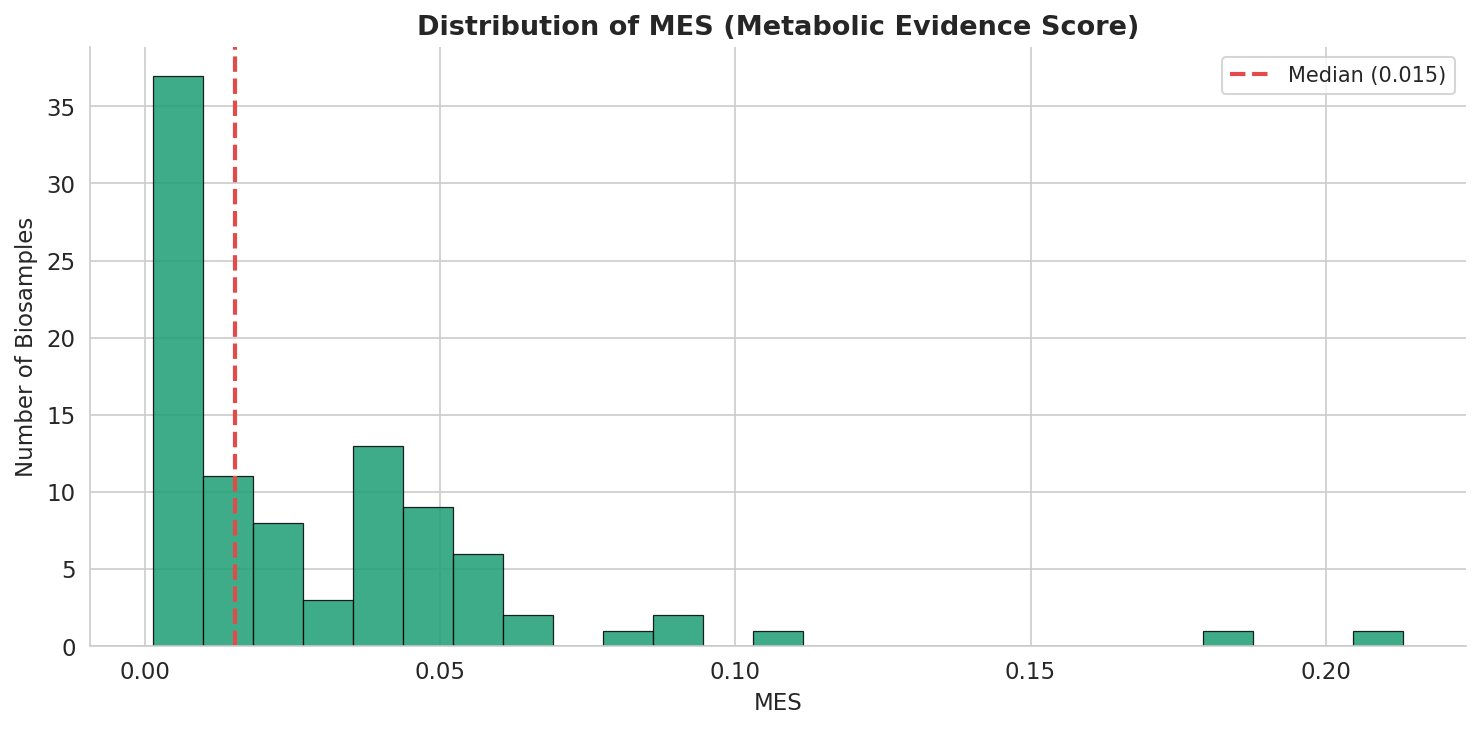

In [12]:
# === 2a. MES DISTRIBUTION ===

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df['MES'], bins=25, edgecolor='black',
        linewidth=0.6, alpha=0.85, color='#1D9E75')
median_mes = df['MES'].median()
ax.axvline(median_mes, color='#E24B4A', linestyle='--', linewidth=2, label=f'Median ({median_mes:.3f})')
ax.set_xlabel('MES')
ax.set_ylabel('Number of Biosamples')
ax.set_title('Distribution of MES (Metabolic Evidence Score)')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/01_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

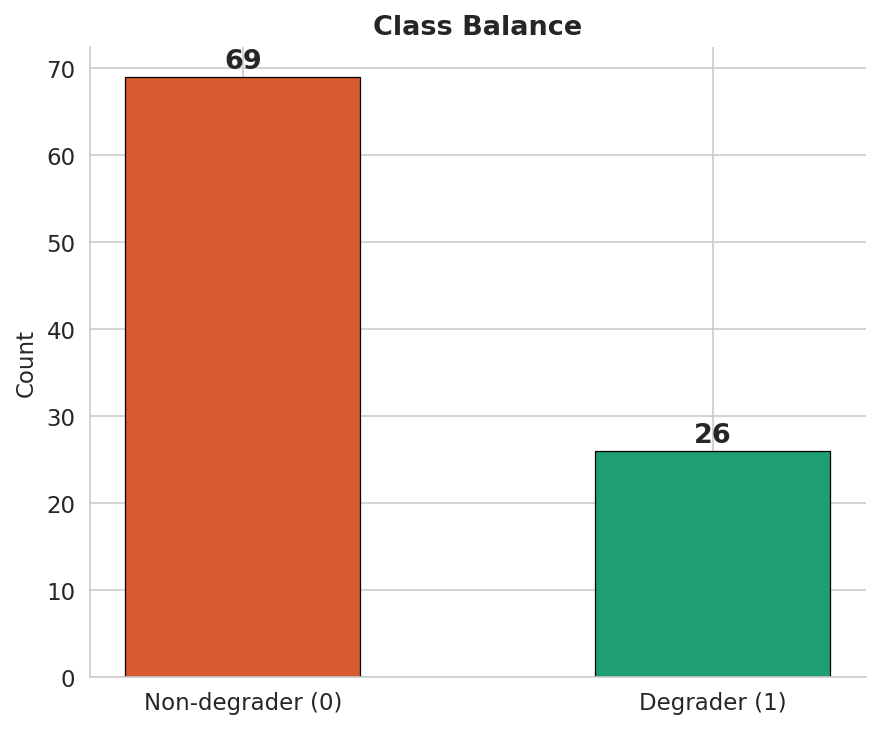

In [13]:
# === 2b. CLASS BALANCE ===

fig, ax = plt.subplots(figsize=(6, 5))
counts = df['MES_label'].value_counts().sort_index()
bars = ax.bar(
    ['Non-degrader (0)', 'Degrader (1)'],
    counts.values,
    color=['#D85A30', '#1D9E75'],
    edgecolor='black', linewidth=0.6, width=0.5
)
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 1, str(v),
            ha='center', fontweight='bold', fontsize=13)
ax.set_ylabel('Count')
ax.set_title('Class Balance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/02_class_balance.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 3. Correlation Analysis

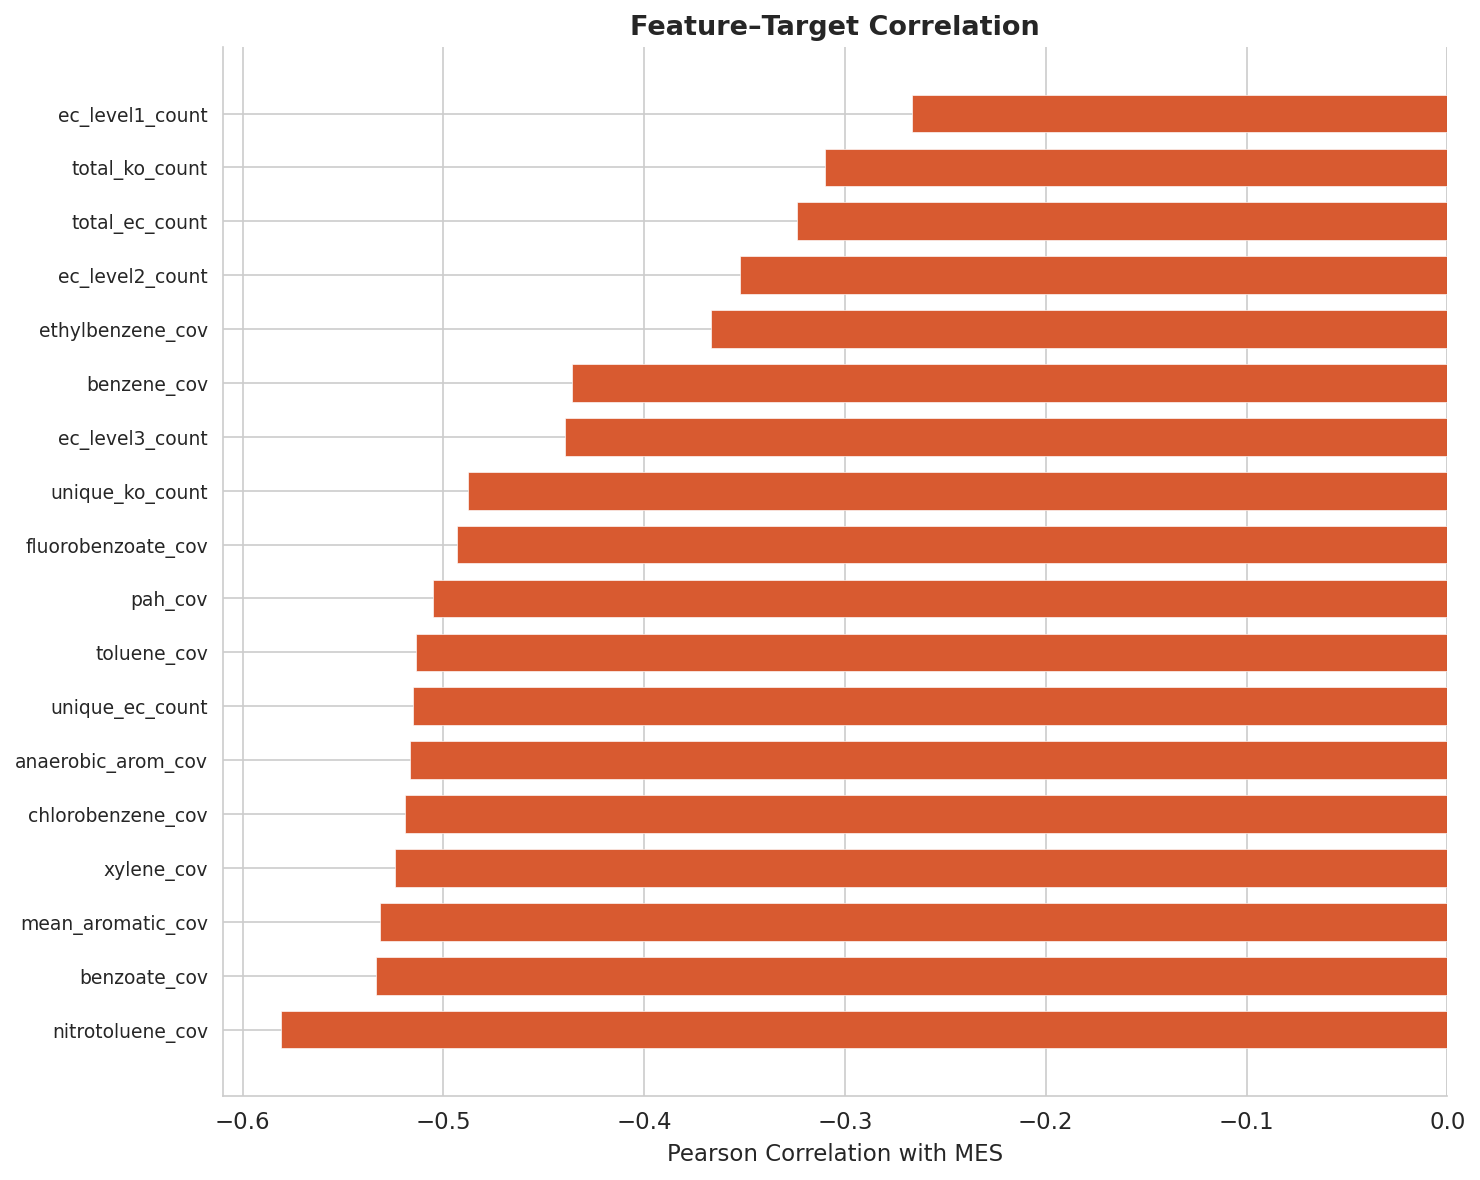

In [14]:
# === 3a. FEATURE-TARGET CORRELATION ===

corr_target = (
    df[feature_cols + ['MES']]
    .corr()['MES']
    .drop('MES')
    .sort_values()
)

# Shorten labels for readability
def shorten_label(name):
    return (
        name
        .replace('_degradation', '')
        .replace('_coverage', '_cov')
        .replace('_presence', '_pres')
        .replace('aromatic_pathway_count', 'arom_path_count')
        .replace('mean_aromatic_coverage', 'mean_arom_cov')
        .replace('anaerobic_aromatic', 'anaerobic_arom')
    )

short_labels = [shorten_label(n) for n in corr_target.index]
colors = ['#1D9E75' if v >= 0 else '#D85A30' for v in corr_target.values]

fig, ax = plt.subplots(figsize=(10, max(8, len(feature_cols) * 0.35)))
ax.barh(range(len(corr_target)), corr_target.values, color=colors, height=0.7, edgecolor='white', linewidth=0.3)
ax.set_yticks(range(len(corr_target)))
ax.set_yticklabels(short_labels, fontsize=9)
ax.set_xlabel('Pearson Correlation with MES')
ax.set_title('Feature–Target Correlation')
ax.axvline(0, color='black', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/03_feature_target_corr.png', dpi=300, bbox_inches='tight')
plt.show()

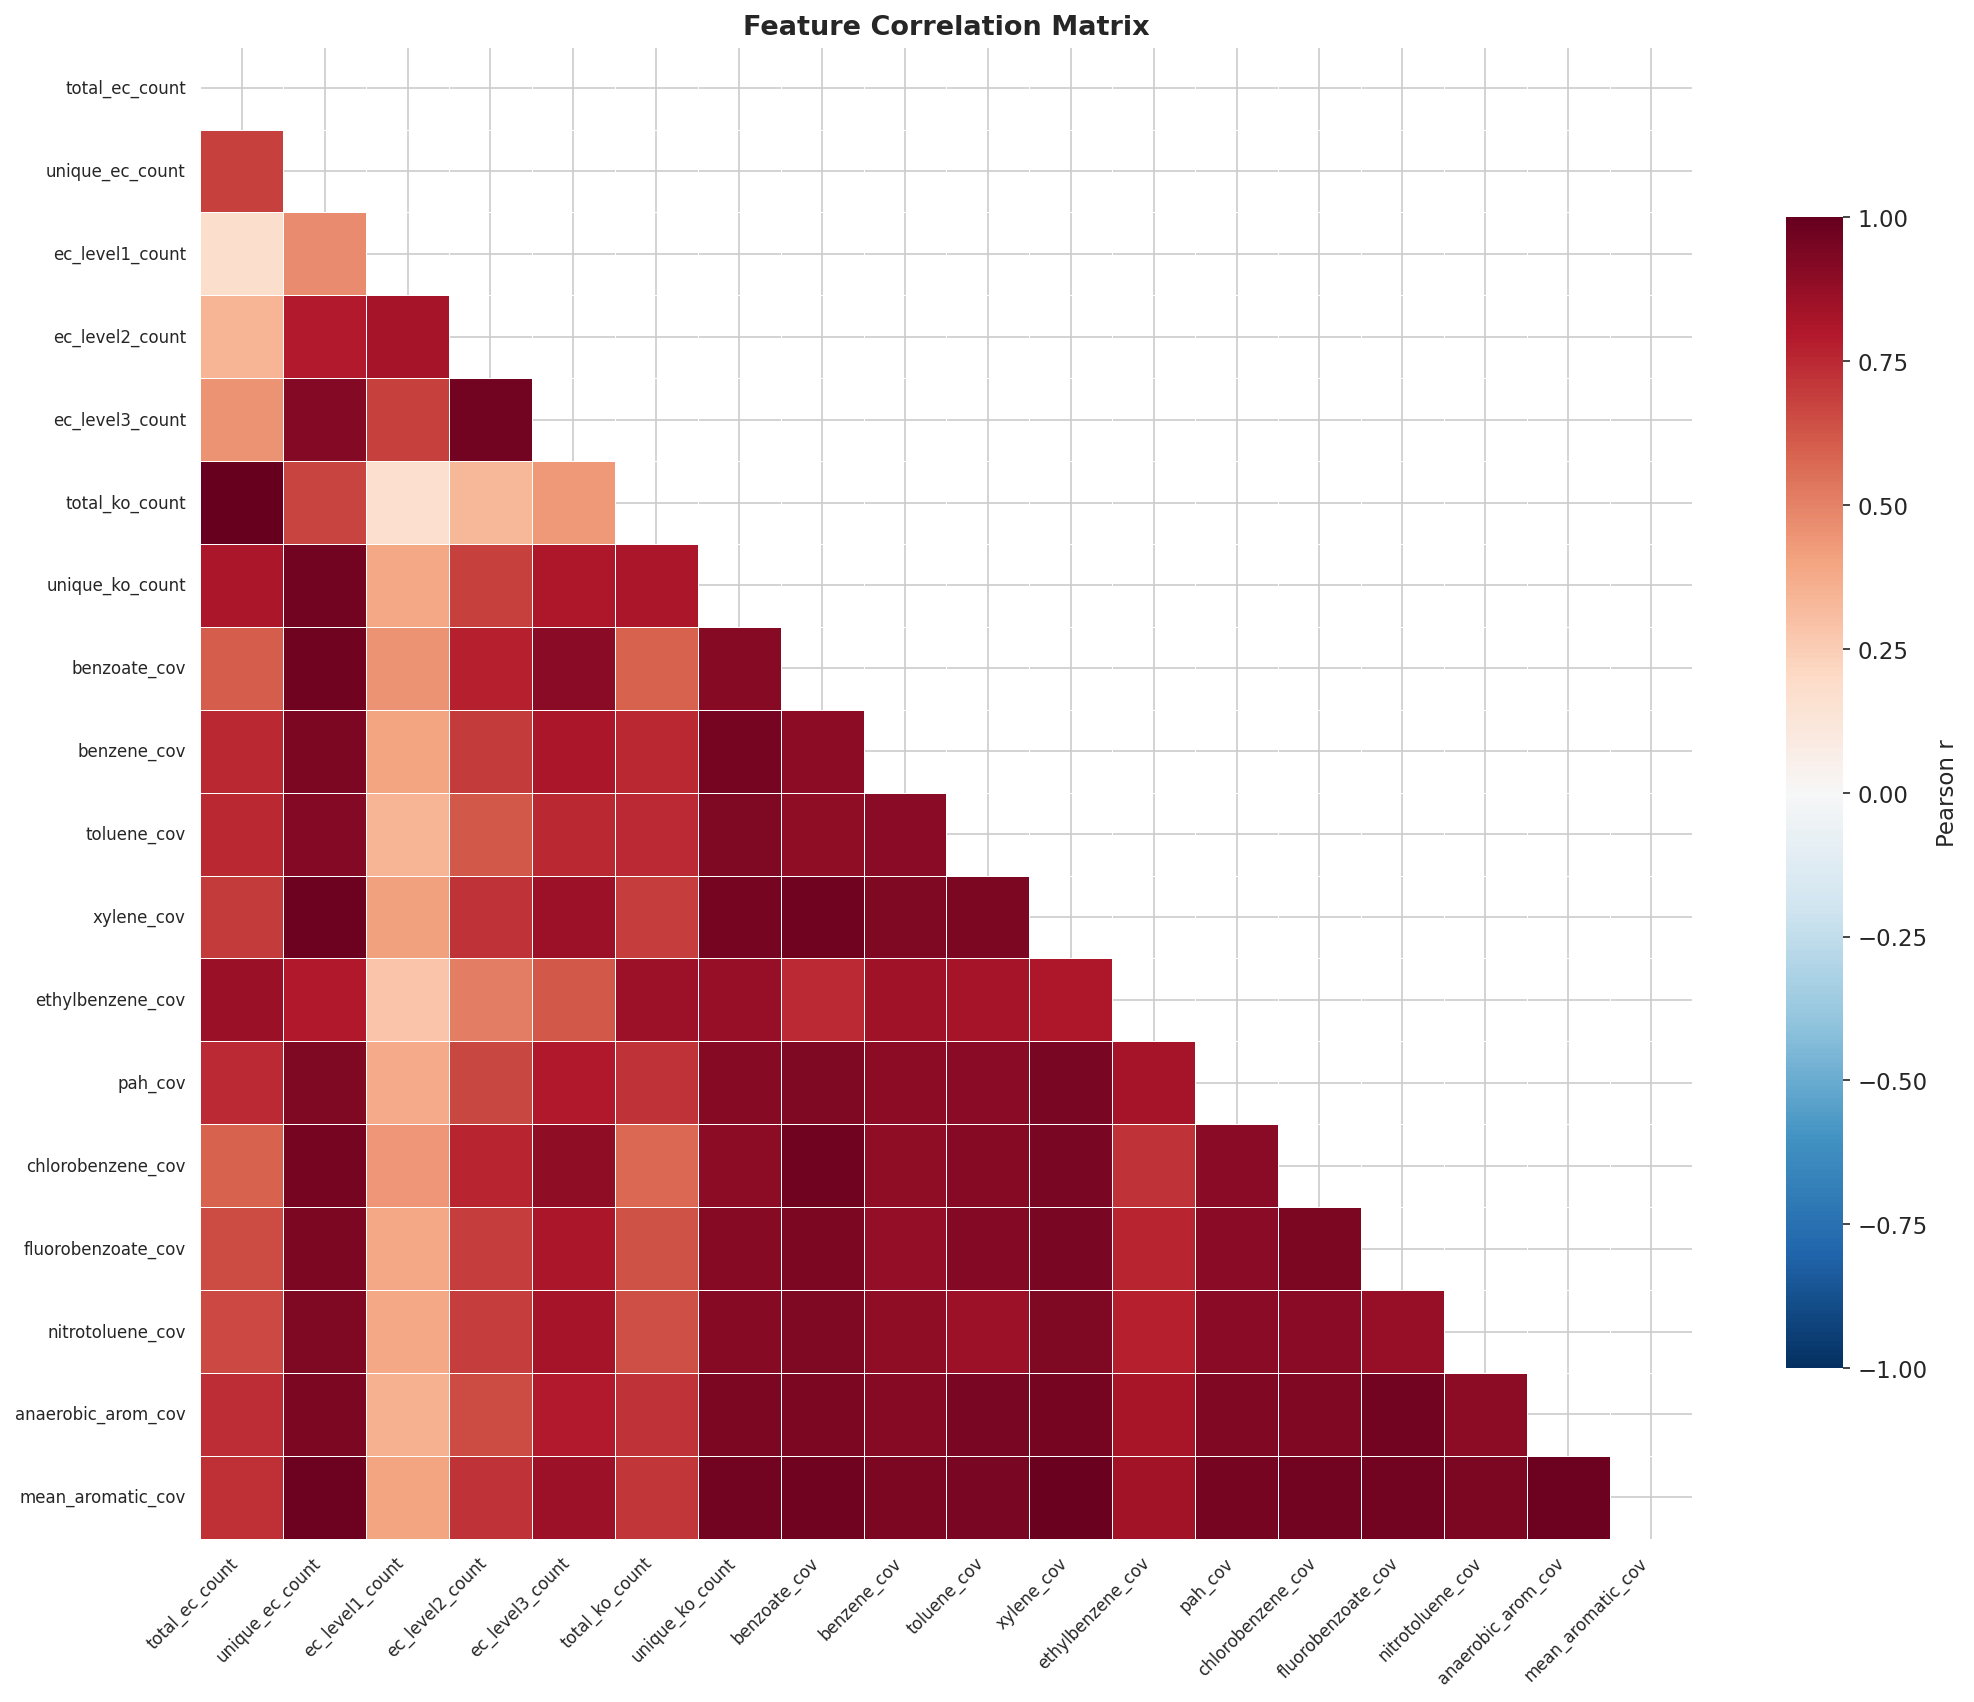

In [15]:
# === 3b. FULL CORRELATION MATRIX ===

corr_matrix = df[feature_cols].corr()
short_feat_labels = [shorten_label(n) for n in feature_cols]

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_matrix, mask=mask, cmap='RdBu_r', center=0,
    ax=ax, square=True,
    xticklabels=short_feat_labels,
    yticklabels=short_feat_labels,
    cbar_kws={'shrink': 0.7, 'label': 'Pearson r'},
    linewidths=0.3, linecolor='white',
    vmin=-1, vmax=1
)
ax.set_title('Feature Correlation Matrix')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/04_corr_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

Top 5 correlated features: ['nitrotoluene_degradation_coverage', 'benzoate_degradation_coverage', 'mean_aromatic_coverage', 'xylene_degradation_coverage', 'chlorobenzene_degradation_coverage']


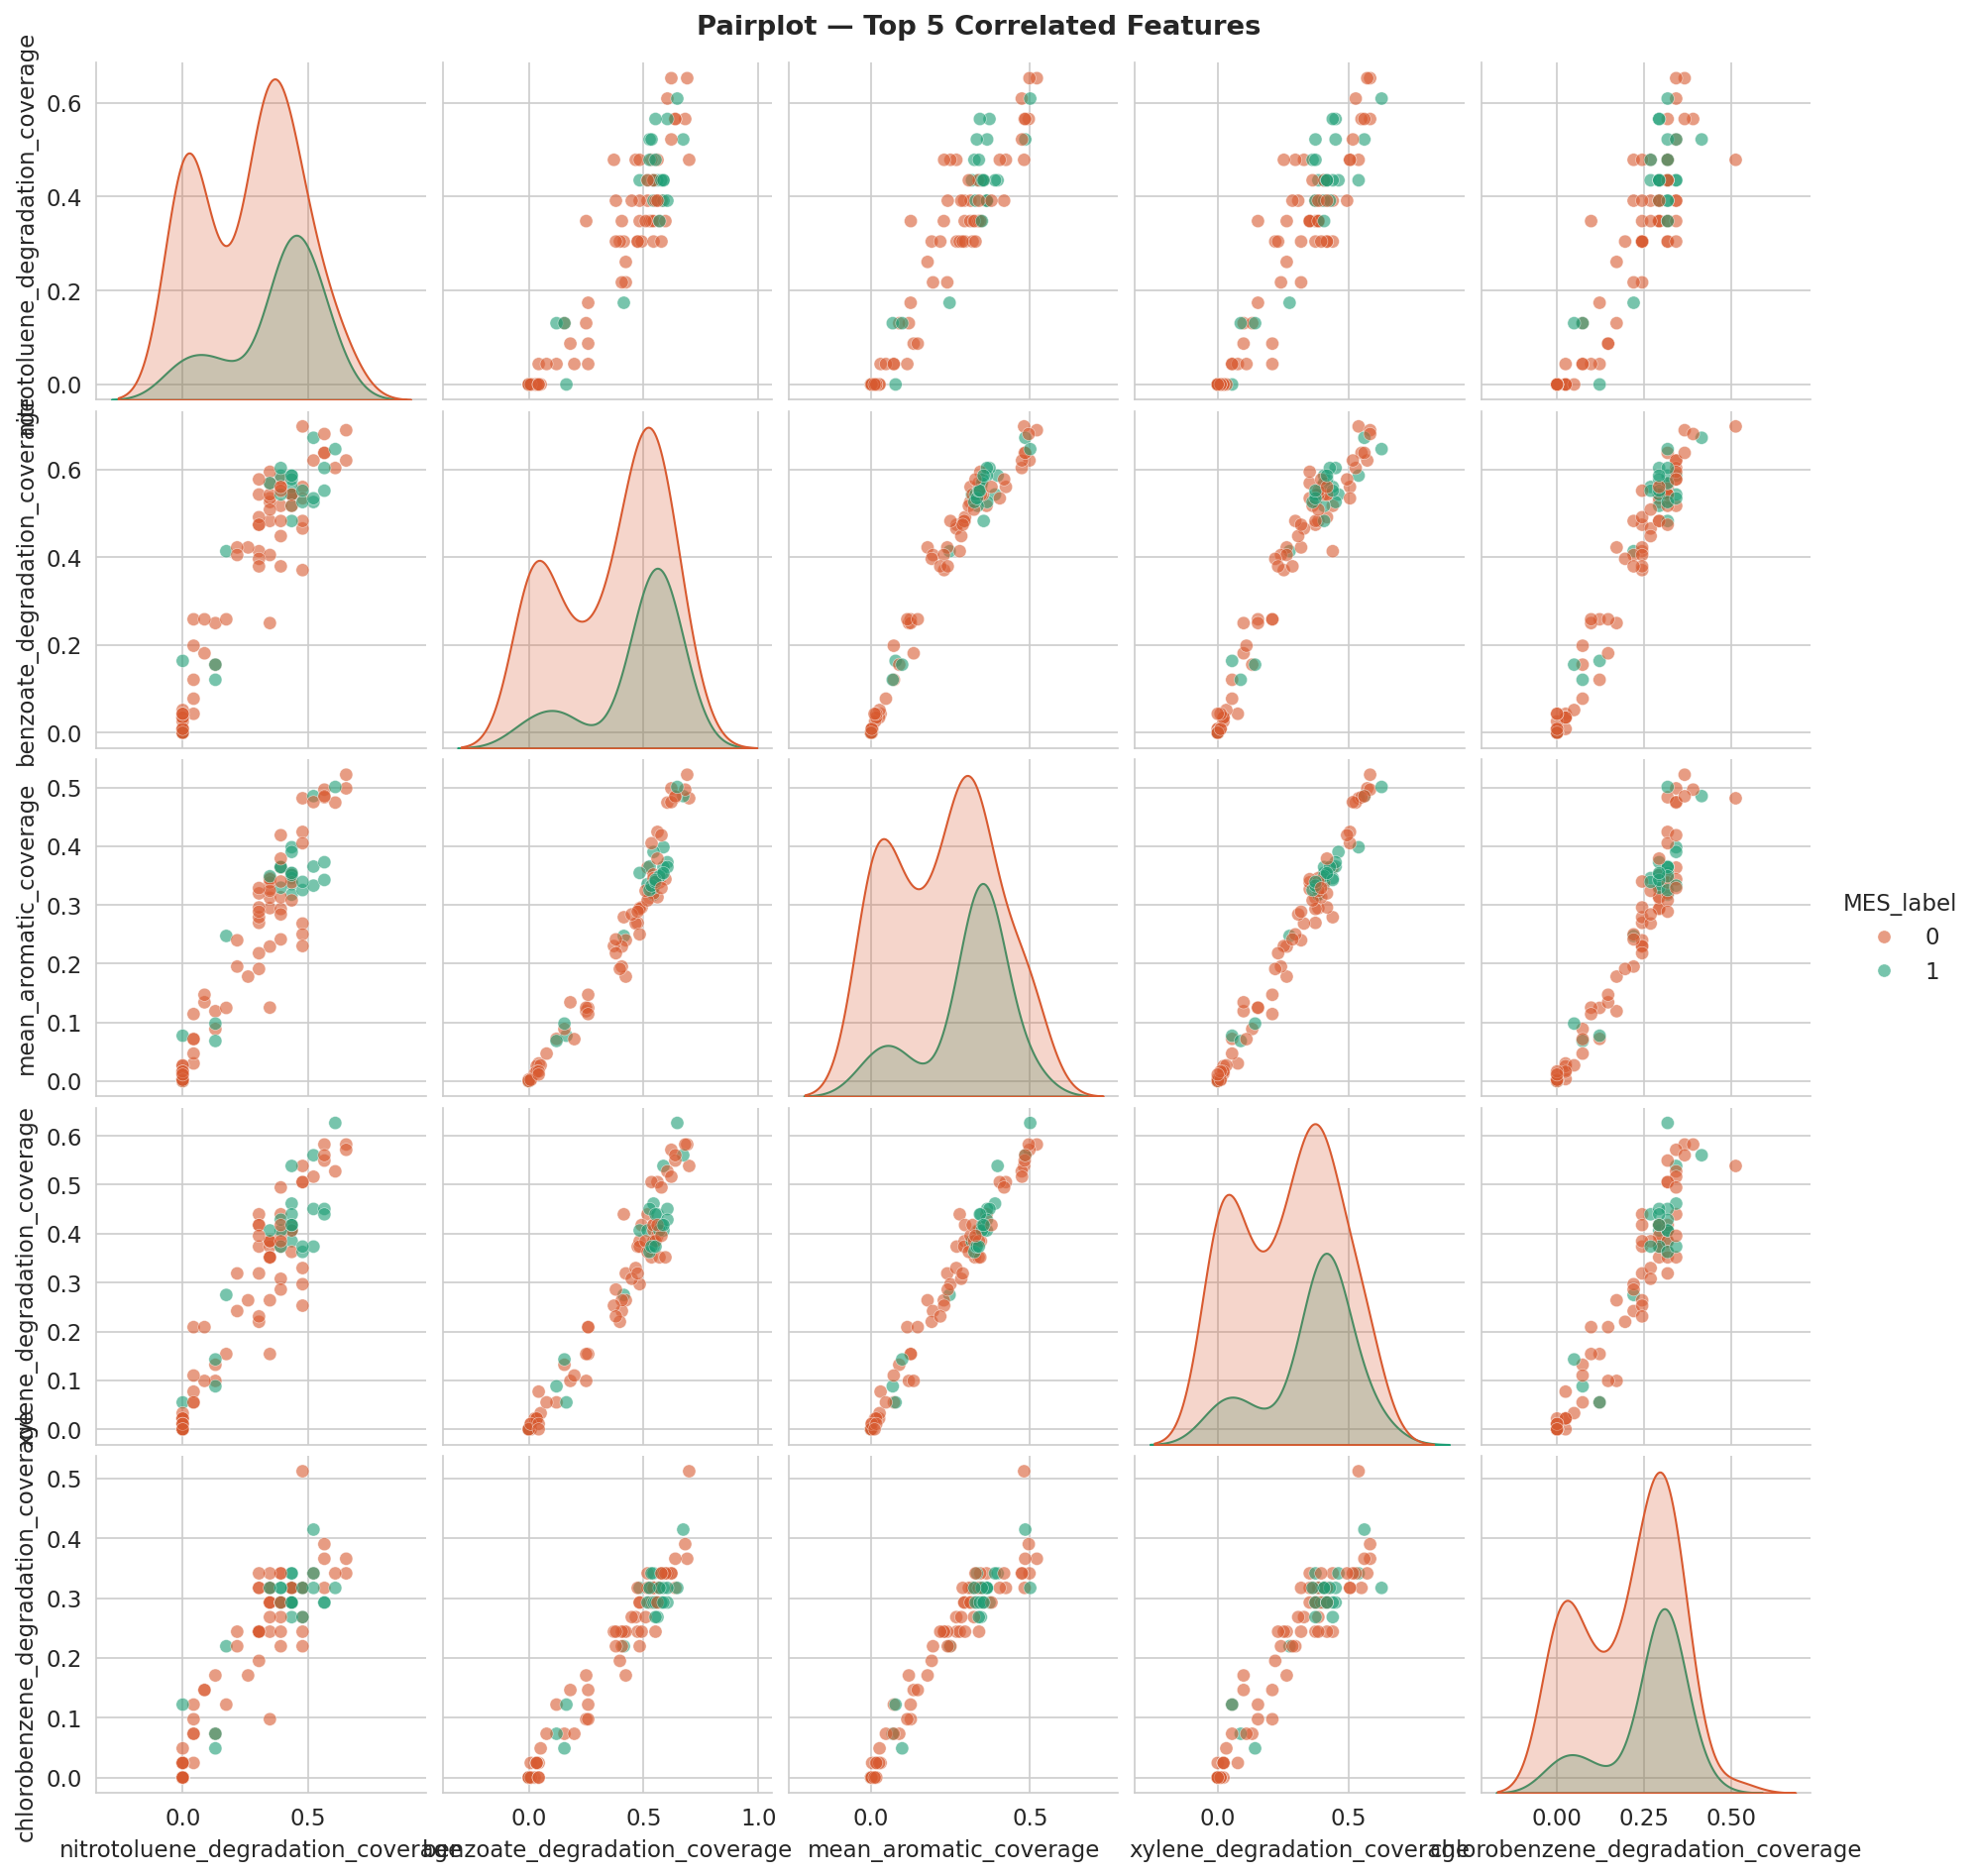

In [16]:
# === 3c. PAIRPLOT — TOP 5 CORRELATED FEATURES ===

top5 = corr_target.abs().sort_values(ascending=False).head(5).index.tolist()
print('Top 5 correlated features:', top5)

g = sns.pairplot(
    df[top5 + ['MES_label']],
    hue='MES_label',
    palette={0: '#D85A30', 1: '#1D9E75'},
    diag_kind='kde',
    plot_kws={'alpha': 0.6, 'edgecolor': 'white', 'linewidth': 0.3, 's': 40},
)
g.figure.suptitle('Pairplot — Top 5 Correlated Features', y=1.01, fontweight='bold')
plt.savefig(f'{FIGDIR}/05_pairplot.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 4. Feature Interpretability (SHAP + Importance)

In [17]:
# === INSTALL SHAP ===
!pip install shap -q

In [18]:
# === 4a. TRAIN RF FOR INTERPRETABILITY ===

import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_squared_error

# Regression target is the continuous MES score (not MES_label),
# so we build X/y directly here instead of using train_model's
# split_features_targets, which is scoped to the classification
# target (MES_label).
X = df[feature_cols]
y_reg = df['MES']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

rf = RandomForestRegressor(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f'RF Regression — R²: {r2_score(y_test, y_pred):.4f}, MSE: {mean_squared_error(y_test, y_pred):.4f}')

RF Regression — R²: 0.1796, MSE: 0.0005


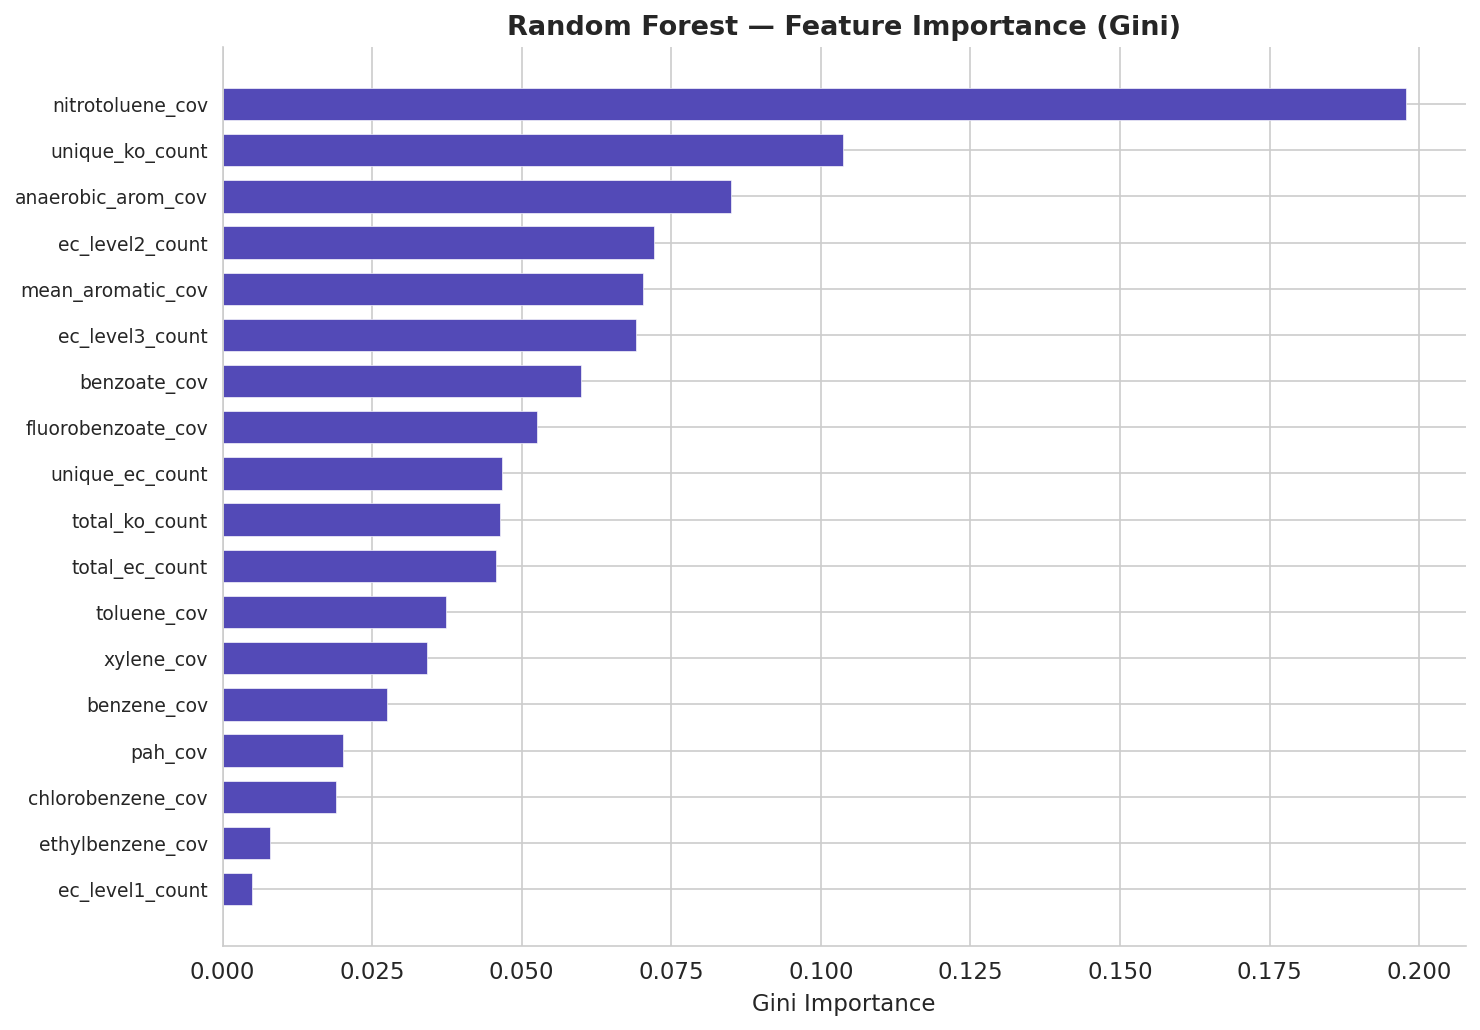

In [19]:
# === 4b. GINI IMPORTANCE (RF built-in) ===

importances = pd.Series(rf.feature_importances_, index=X.columns)
imp_sorted = importances.sort_values(ascending=True)
short_imp_labels = [shorten_label(n) for n in imp_sorted.index]

fig, ax = plt.subplots(figsize=(10, max(7, len(feature_cols) * 0.32)))
ax.barh(
    range(len(imp_sorted)), imp_sorted.values,
    color='#534AB7', height=0.7, edgecolor='white', linewidth=0.3
)
ax.set_yticks(range(len(imp_sorted)))
ax.set_yticklabels(short_imp_labels, fontsize=9)
ax.set_xlabel('Gini Importance')
ax.set_title('Random Forest — Feature Importance (Gini)')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/06_gini_importance.png', dpi=300, bbox_inches='tight')
plt.show()

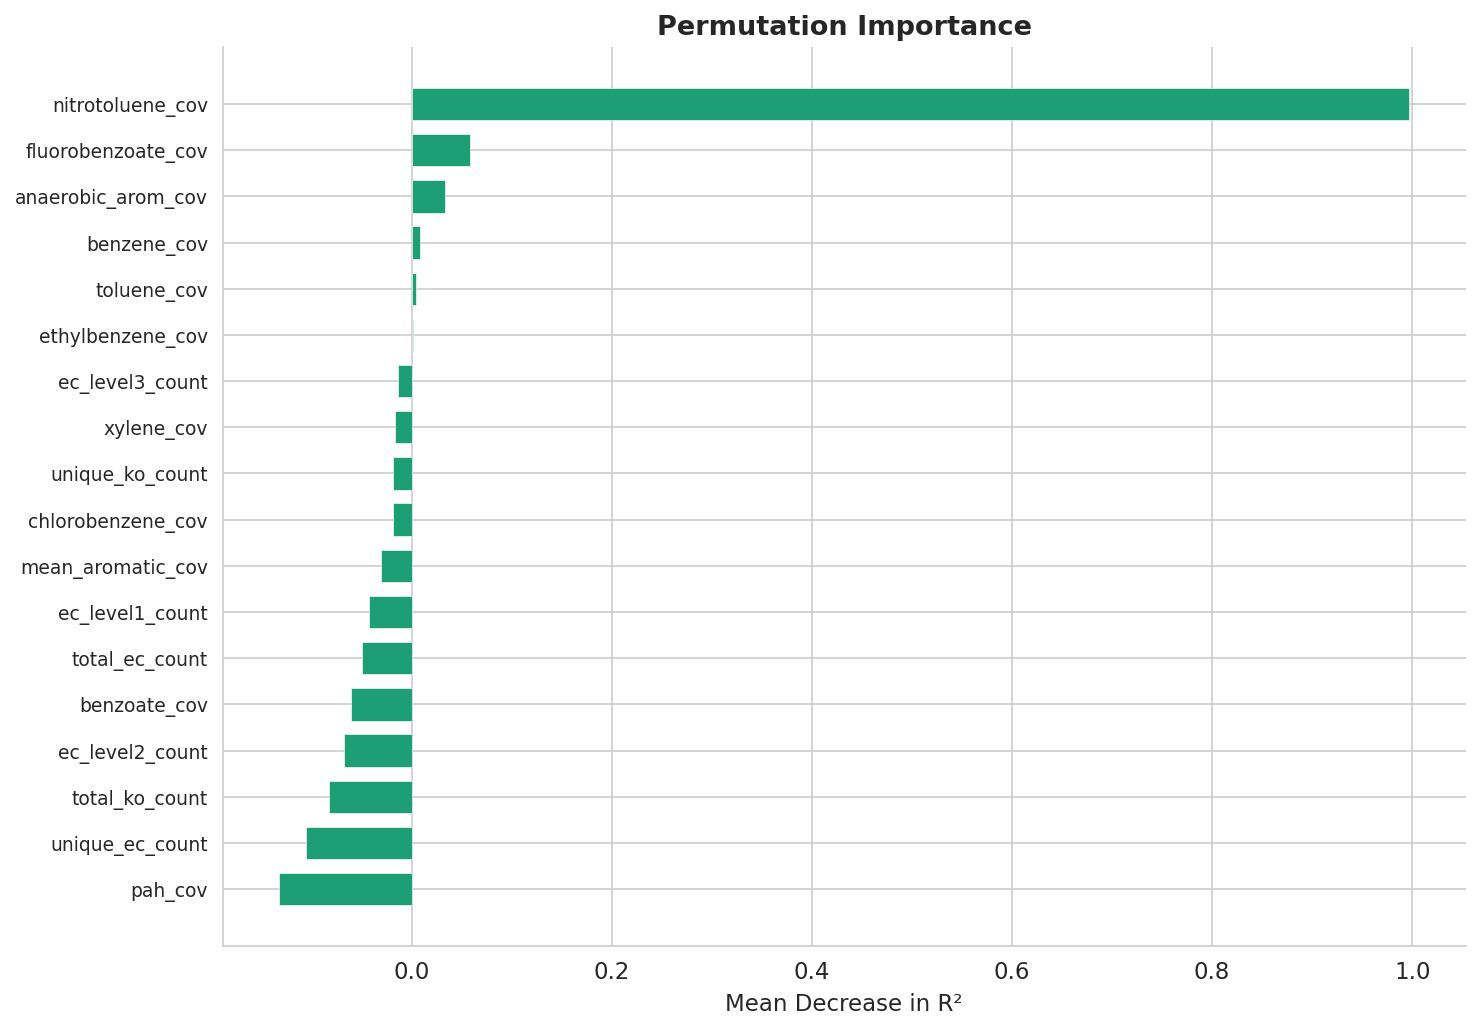

In [20]:
# === 4c. PERMUTATION IMPORTANCE ===

perm_imp = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42)
perm_series = pd.Series(perm_imp.importances_mean, index=X.columns).sort_values(ascending=True)
short_perm_labels = [shorten_label(n) for n in perm_series.index]

fig, ax = plt.subplots(figsize=(10, max(7, len(feature_cols) * 0.32)))
ax.barh(
    range(len(perm_series)), perm_series.values,
    color='#1D9E75', height=0.7, edgecolor='white', linewidth=0.3
)
ax.set_yticks(range(len(perm_series)))
ax.set_yticklabels(short_perm_labels, fontsize=9)
ax.set_xlabel('Mean Decrease in R²')
ax.set_title('Permutation Importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/07_permutation_importance.png', dpi=300, bbox_inches='tight')
plt.show()

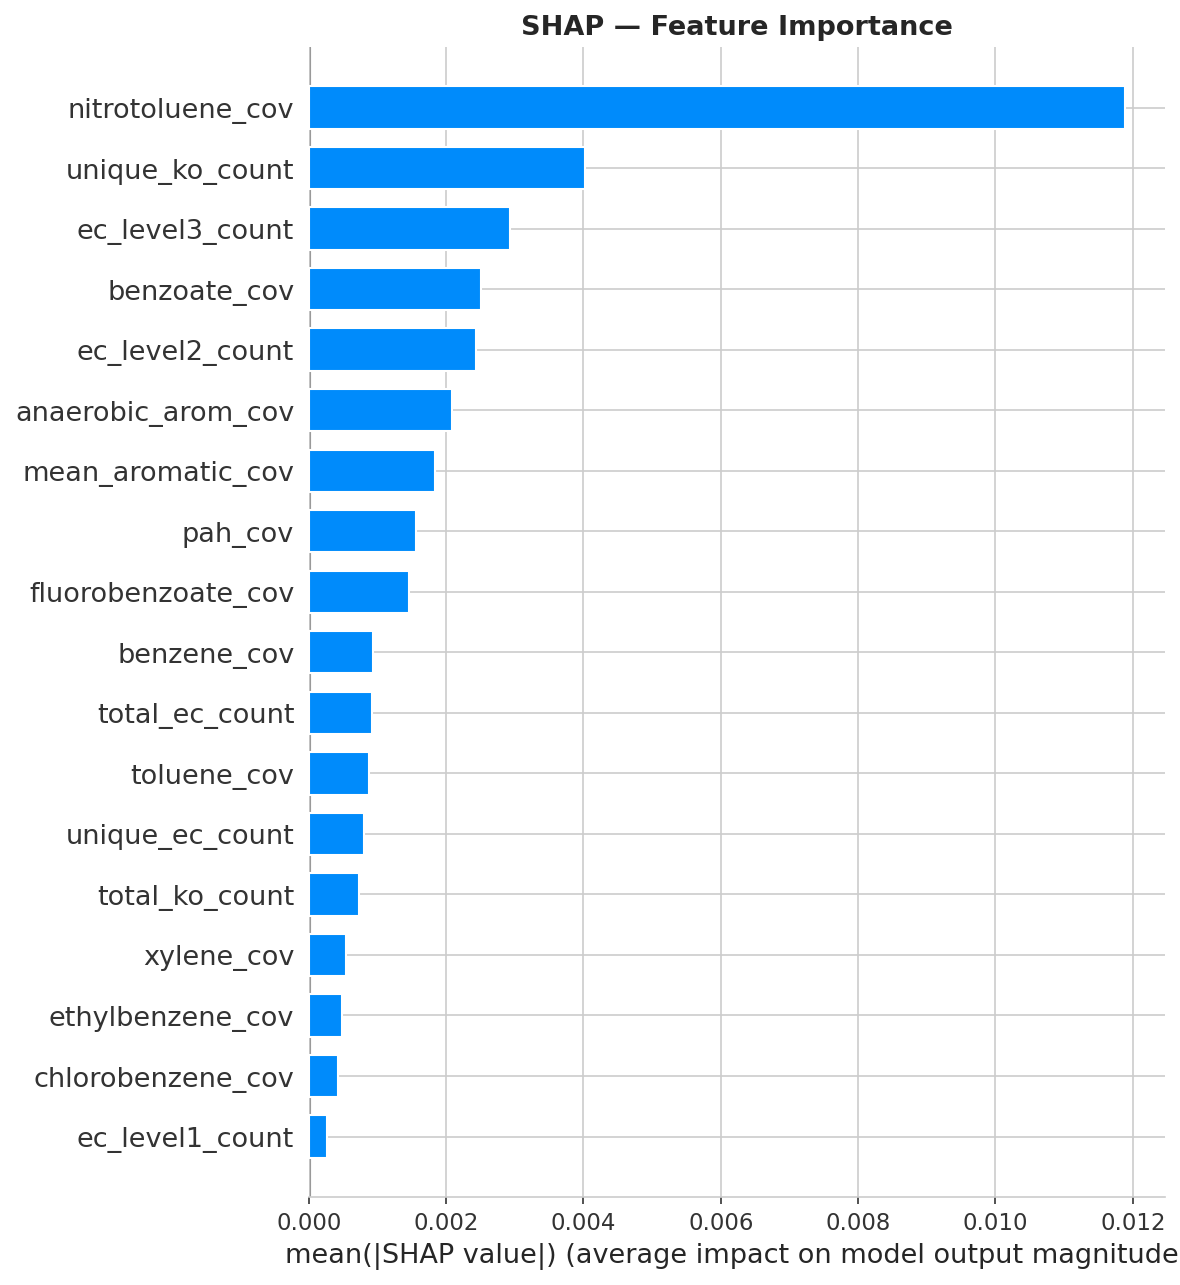

In [21]:
# === 4d. SHAP — BAR PLOT ===

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)

# Rename columns for cleaner SHAP plots
X_test_short = X_test.copy()
X_test_short.columns = [shorten_label(c) for c in X_test.columns]

fig, ax = plt.subplots(figsize=(10, max(7, len(feature_cols) * 0.32)))
shap.summary_plot(shap_values, X_test_short, plot_type='bar', show=False, max_display=len(feature_cols))
plt.title('SHAP — Feature Importance', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/08_shap_bar.png', dpi=300, bbox_inches='tight')
plt.show()

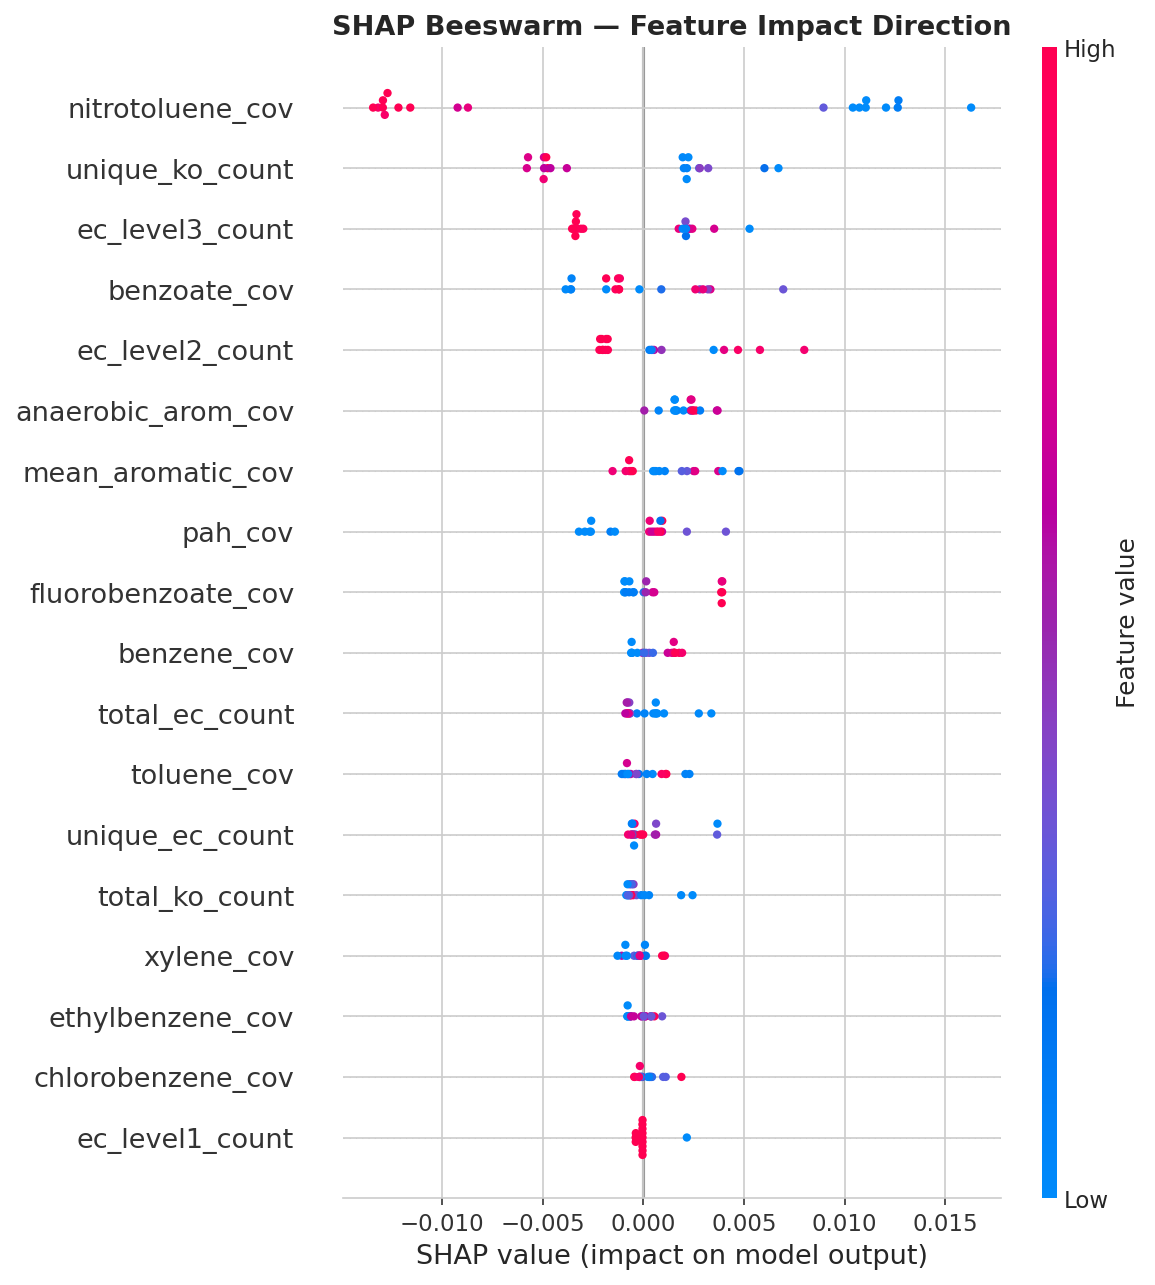

In [22]:
# === 4e. SHAP — BEESWARM (direction of impact) ===

fig, ax = plt.subplots(figsize=(10, max(7, len(feature_cols) * 0.32)))
shap.summary_plot(shap_values, X_test_short, show=False, max_display=len(feature_cols))
plt.title('SHAP Beeswarm — Feature Impact Direction', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/09_shap_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

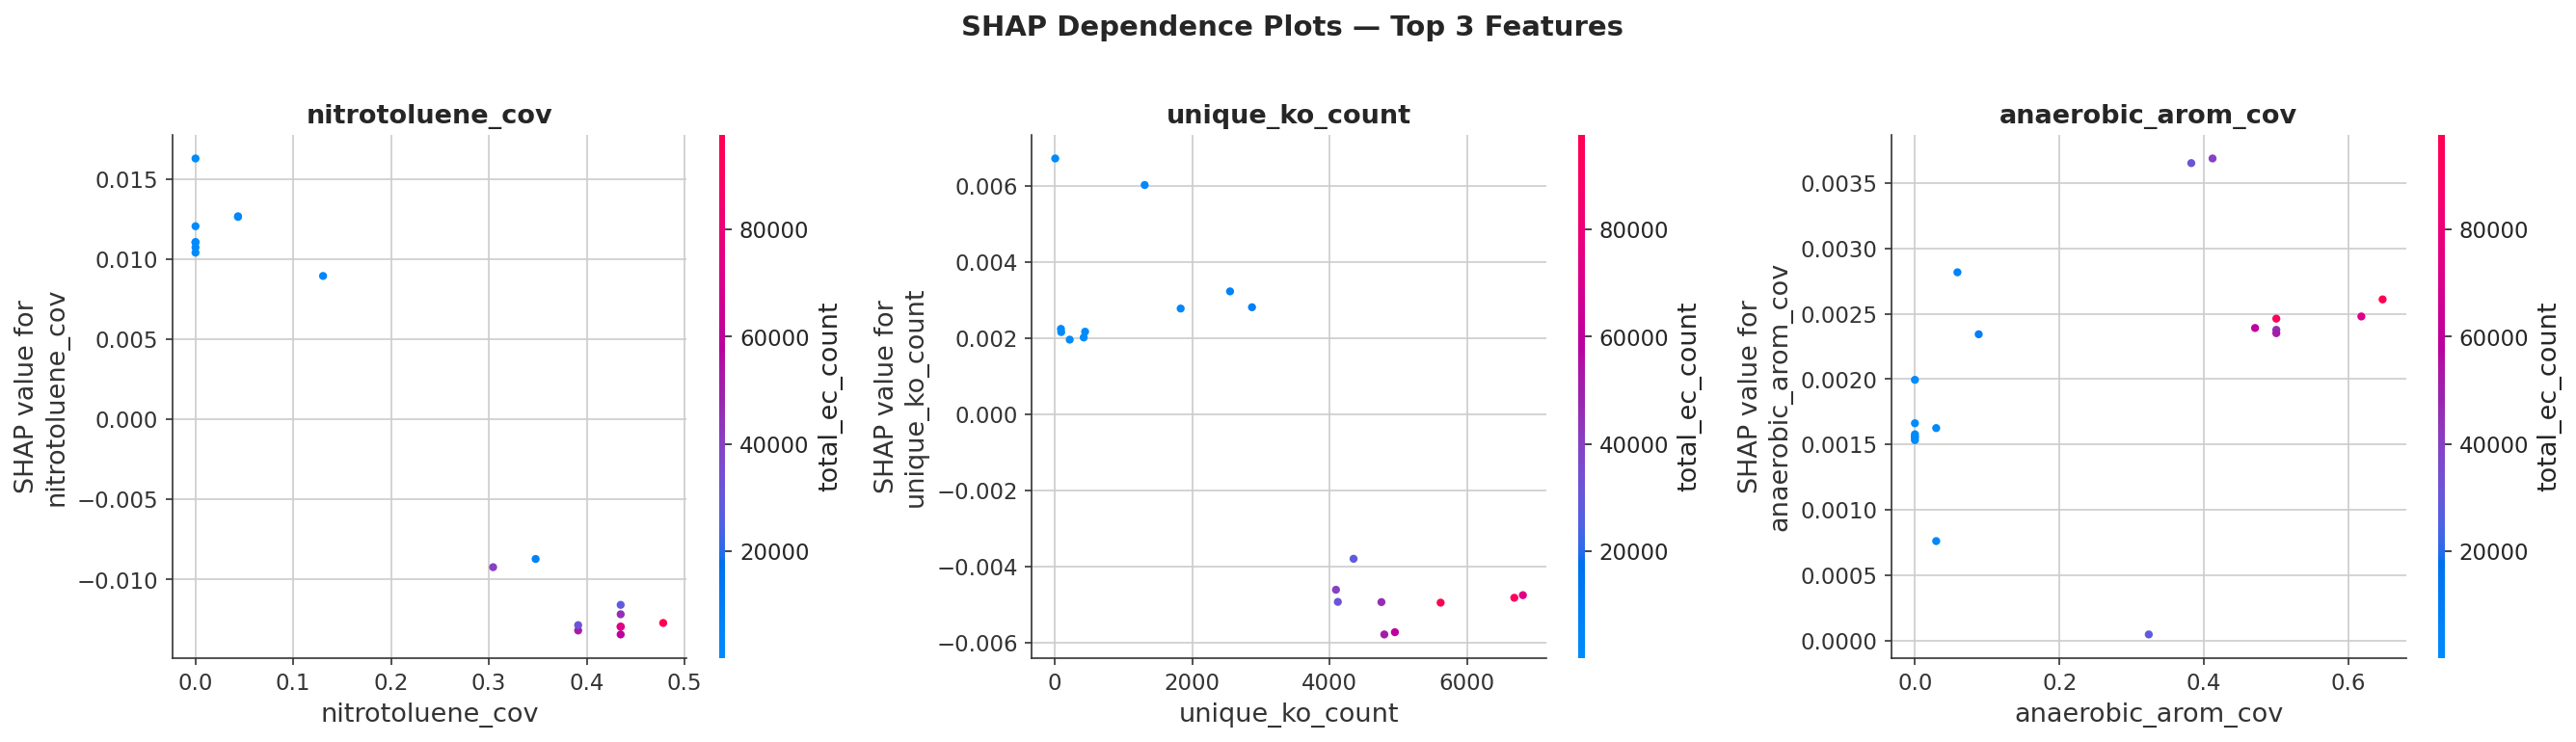

In [23]:
# === 4f. SHAP DEPENDENCE — TOP 3 FEATURES ===

top3 = importances.sort_values(ascending=False).head(3).index.tolist()
top3_idx = [list(X_test.columns).index(f) for f in top3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (feat, idx) in enumerate(zip(top3, top3_idx)):
    shap.dependence_plot(
        idx, shap_values, X_test_short,
        ax=axes[i], show=False
    )
    axes[i].set_title(shorten_label(feat), fontweight='bold')
plt.suptitle('SHAP Dependence Plots — Top 3 Features', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/10_shap_dependence.png', dpi=300, bbox_inches='tight')
plt.show()

In [24]:
# === 4g. IMPORTANCE COMPARISON TABLE ===

# Combine all importance metrics into one table
shap_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X.columns
)

importance_table = pd.DataFrame({
    'Feature': [shorten_label(f) for f in X.columns],
    'Gini Importance': importances.values,
    'Permutation Imp.': pd.Series(perm_imp.importances_mean, index=X.columns).values,
    'SHAP (mean |val|)': shap_importance.values,
}).sort_values('Gini Importance', ascending=False).reset_index(drop=True)

# Rank columns
importance_table['Gini Rank'] = importance_table['Gini Importance'].rank(ascending=False).astype(int)
importance_table['Perm Rank'] = importance_table['Permutation Imp.'].rank(ascending=False).astype(int)
importance_table['SHAP Rank'] = importance_table['SHAP (mean |val|)'].rank(ascending=False).astype(int)

display(importance_table.style
    .set_caption('Feature Importance — All Methods Compared')
    .format({
        'Gini Importance': '{:.4f}',
        'Permutation Imp.': '{:.4f}',
        'SHAP (mean |val|)': '{:.4f}',
    })
    .hide(axis='index')
    .background_gradient(subset=['Gini Importance'], cmap='Purples')
    .background_gradient(subset=['Permutation Imp.'], cmap='Greens')
    .background_gradient(subset=['SHAP (mean |val|)'], cmap='Blues')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px'), ('font-size', '10px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('font-size', '10px')]},
    ])
)

Feature,Gini Importance,Permutation Imp.,SHAP (mean |val|),Gini Rank,Perm Rank,SHAP Rank
nitrotoluene_cov,0.1979,0.9968,0.0119,1,1,1
unique_ko_count,0.1036,-0.0185,0.0040,2,9,2
anaerobic_arom_cov,0.0850,0.0337,0.0021,3,3,6
ec_level2_count,0.0721,-0.0673,0.0024,4,15,5
mean_aromatic_cov,0.0703,-0.0310,0.0018,5,11,7
ec_level3_count,0.0691,-0.0137,0.0029,6,7,3
benzoate_cov,0.0600,-0.0603,0.0025,7,14,4
fluorobenzoate_cov,0.0525,0.0580,0.0015,8,2,9
unique_ec_count,0.0466,-0.1056,0.0008,9,17,13
total_ko_count,0.0464,-0.0831,0.0007,10,16,14


---
## 5. Unsupervised Learning

In [25]:
# === INSTALL UMAP ===
!pip install umap-learn -q

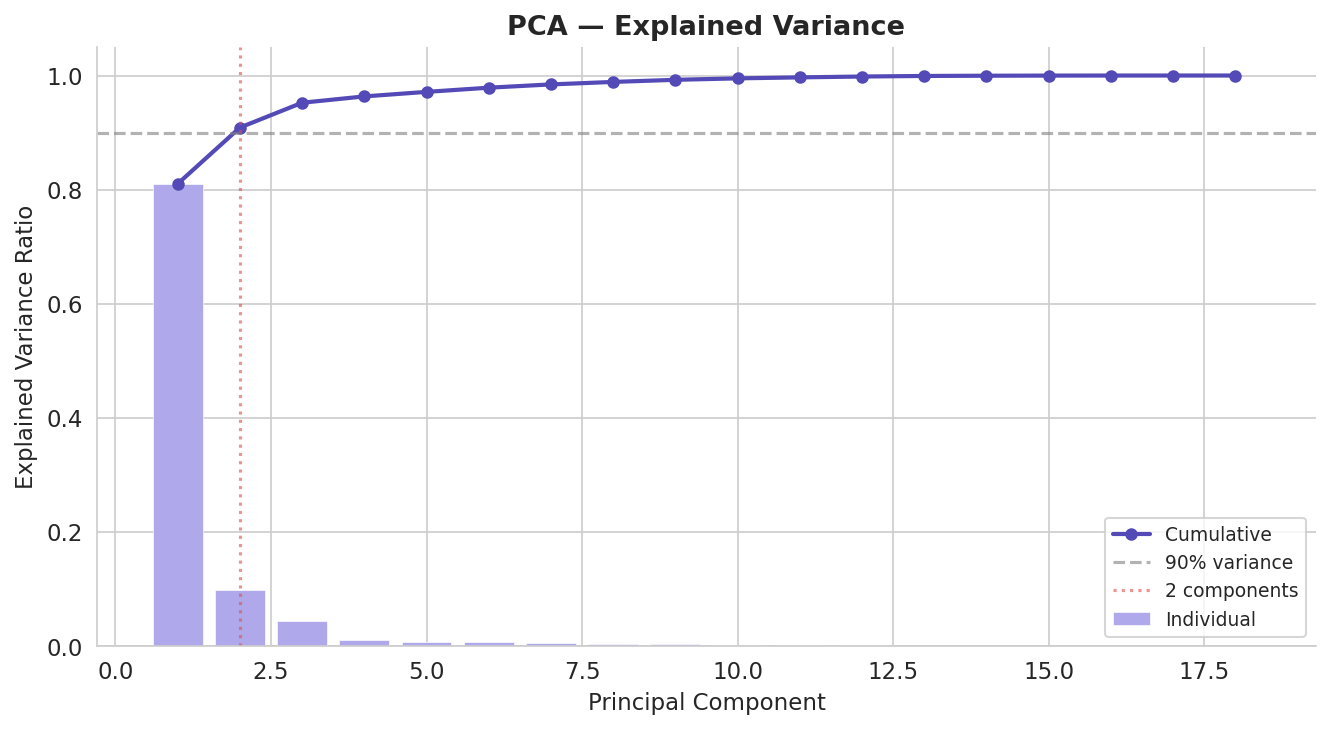

2 components explain 90% of variance


In [26]:
# === 5a. PCA — EXPLAINED VARIANCE ===

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X_feat = df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)
n_90 = np.argmax(cumvar >= 0.90) + 1

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(range(1, len(cumvar) + 1), pca.explained_variance_ratio_,
       color='#AFA9EC', edgecolor='white', linewidth=0.3, label='Individual')
ax.plot(range(1, len(cumvar) + 1), cumvar, 'o-', color='#534AB7',
        markersize=5, linewidth=2, label='Cumulative')
ax.axhline(0.90, linestyle='--', color='gray', alpha=0.6, label='90% variance')
ax.axvline(n_90, linestyle=':', color='#E24B4A', alpha=0.6, label=f'{n_90} components')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA — Explained Variance')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/11_pca_variance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'{n_90} components explain 90% of variance')

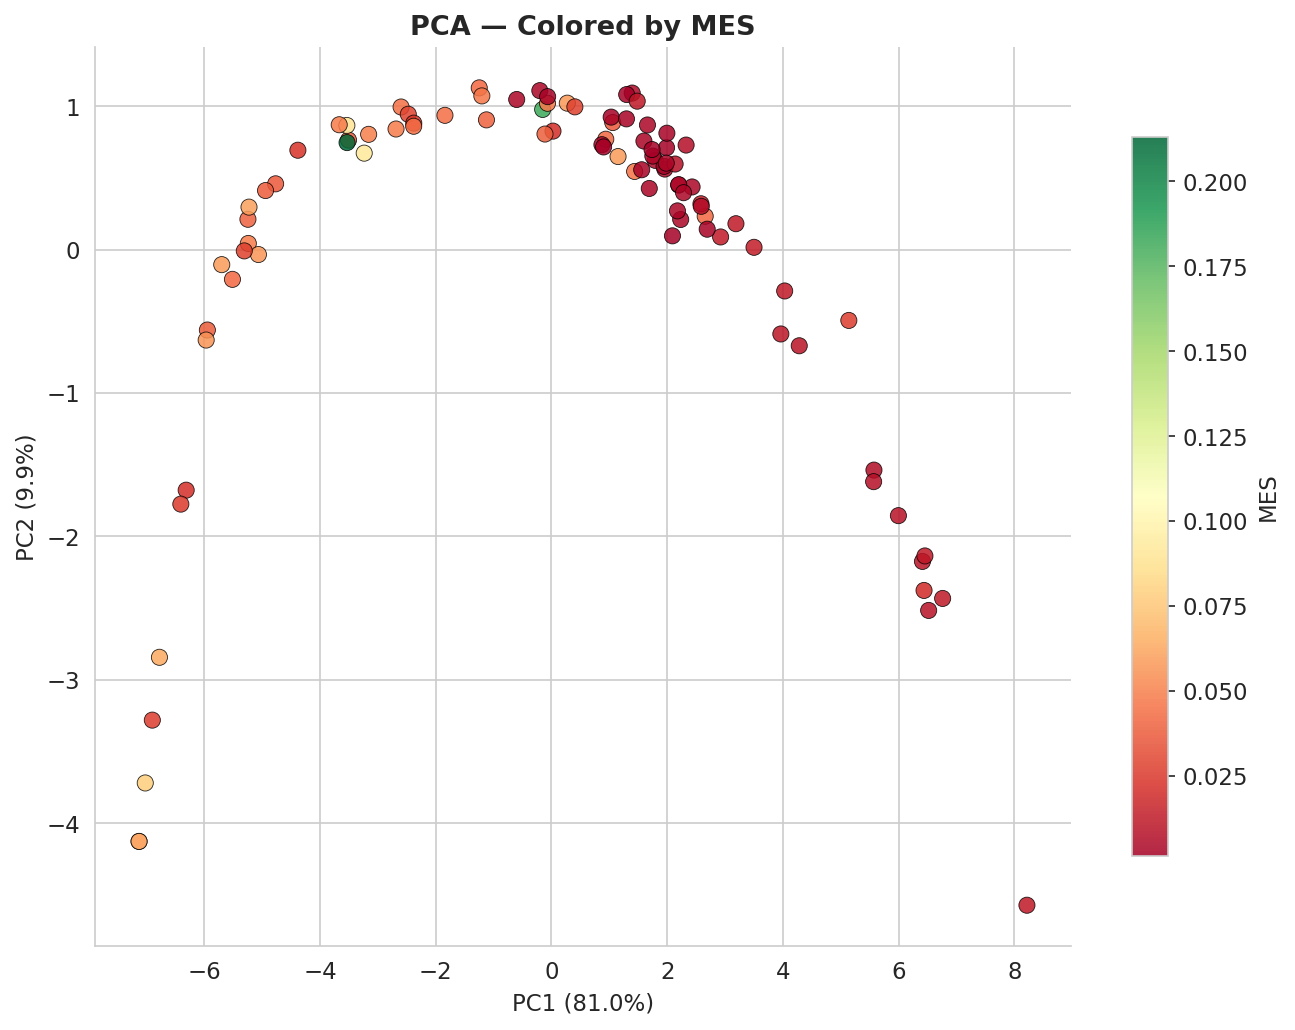

In [27]:
# === 5b. PCA SCATTER — COLORED BY MES ===

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['MES'], cmap='RdYlGn',
    edgecolors='black', linewidth=0.4, s=60, alpha=0.85
)
plt.colorbar(sc, ax=ax, label='MES', shrink=0.8)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA — Colored by MES')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/12_pca_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

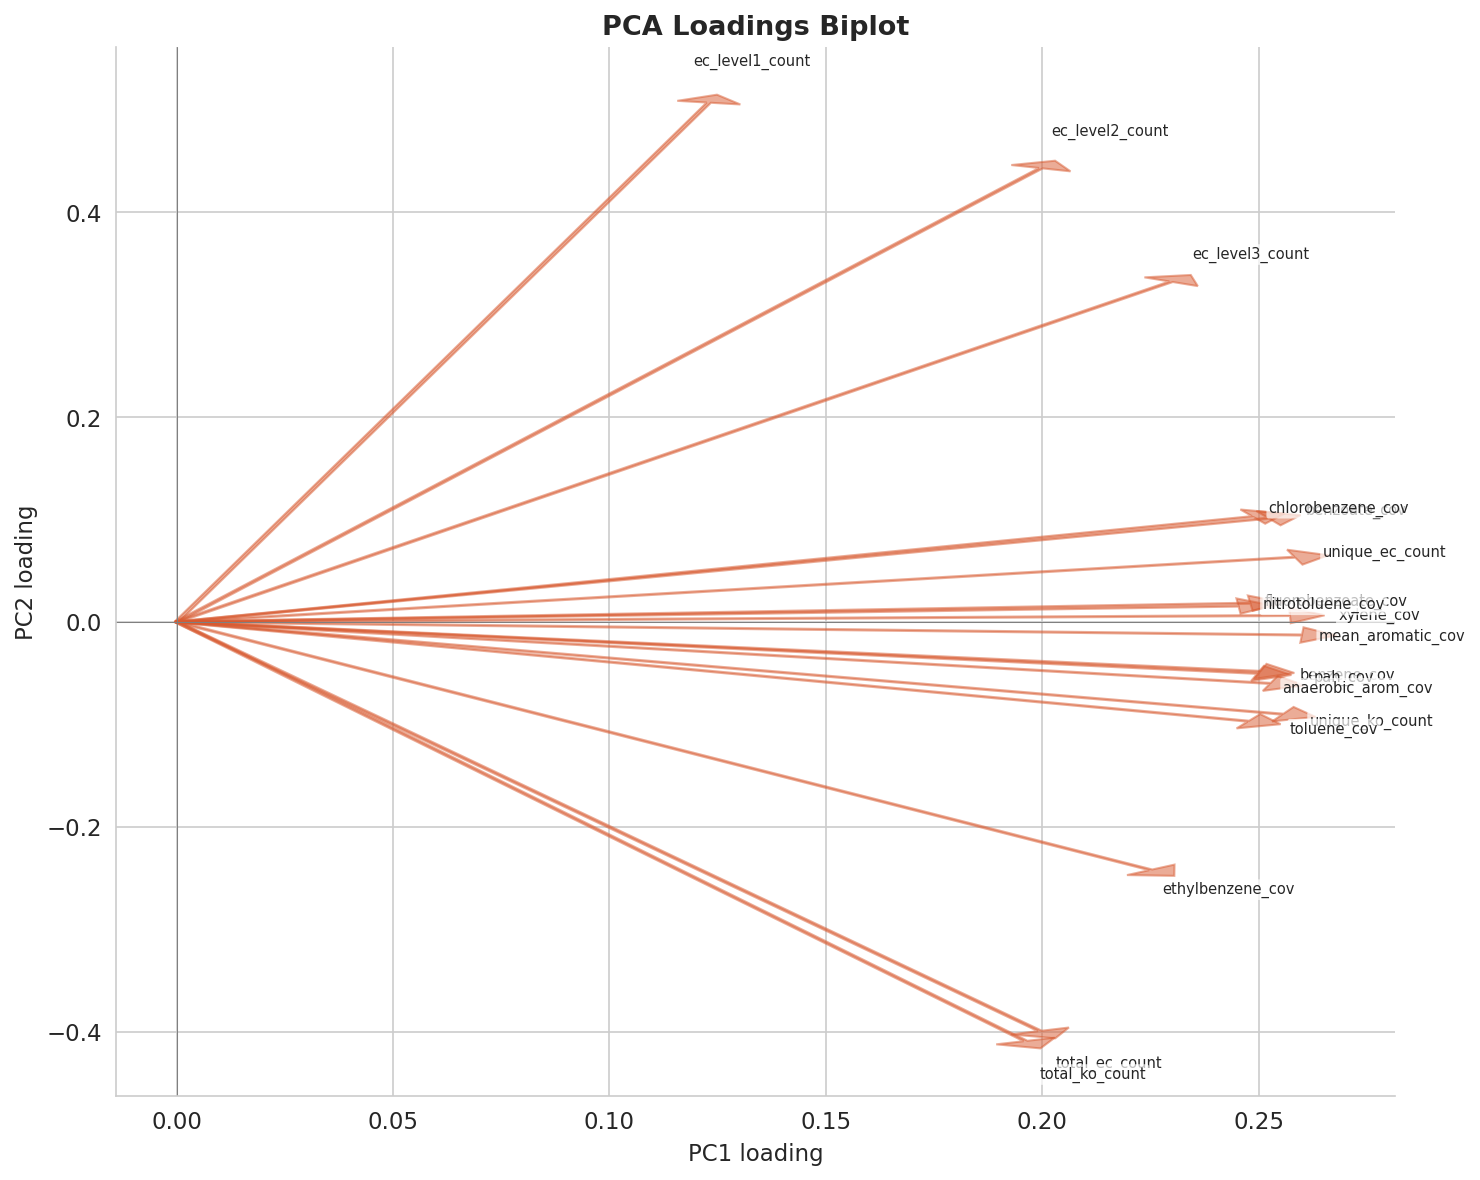

In [28]:
# === 5c. PCA BIPLOT (LOADINGS) ===

loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=feature_cols
)

fig, ax = plt.subplots(figsize=(10, 8))
for feat in feature_cols:
    x, y = loadings.loc[feat, 'PC1'], loadings.loc[feat, 'PC2']
    ax.arrow(0, 0, x, y, head_width=0.015, head_length=0.008,
             fc='#D85A30', ec='#D85A30', alpha=0.5)
    ax.annotate(
        shorten_label(feat),
        (x * 1.08, y * 1.08),
        fontsize=7, ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7)
    )
ax.set_xlabel('PC1 loading')
ax.set_ylabel('PC2 loading')
ax.set_title('PCA Loadings Biplot')
ax.axhline(0, color='gray', linewidth=0.5)
ax.axvline(0, color='gray', linewidth=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/13_pca_biplot.png', dpi=300, bbox_inches='tight')
plt.show()

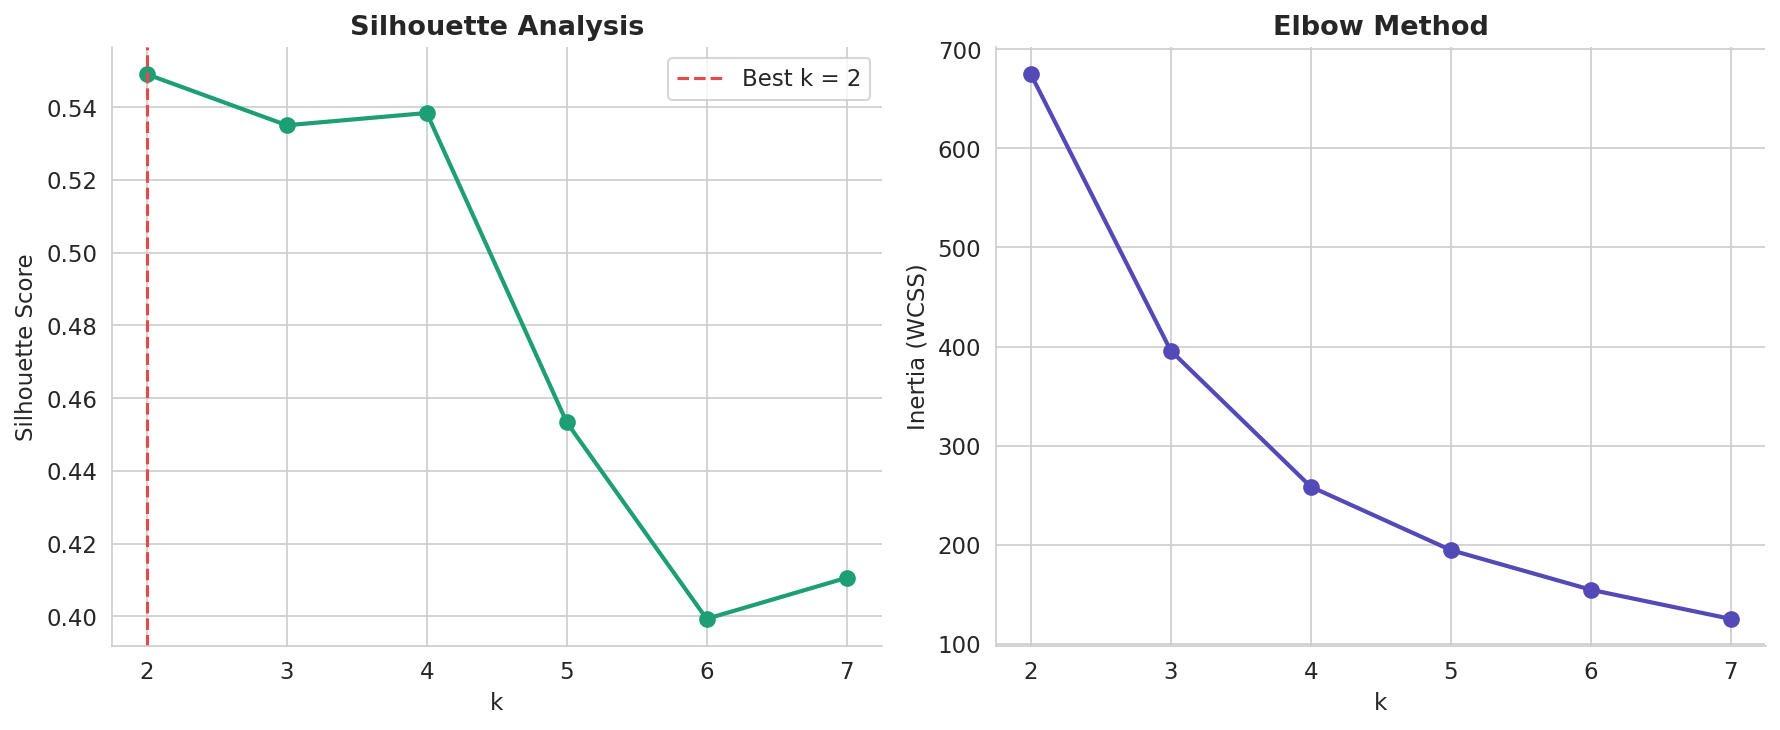

Best k by silhouette: 2


In [29]:
# === 5d. K-MEANS — SILHOUETTE ANALYSIS ===

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

K_range = range(2, min(8, len(df) // 3))
silhouettes = []
inertias = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, labels))
    inertias.append(km.inertia_)

best_k = list(K_range)[np.argmax(silhouettes)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(list(K_range), silhouettes, 'o-', color='#1D9E75', linewidth=2, markersize=7)
ax1.axvline(best_k, linestyle='--', color='#E24B4A', label=f'Best k = {best_k}')
ax1.set_xlabel('k')
ax1.set_ylabel('Silhouette Score')
ax1.set_title('Silhouette Analysis')
ax1.legend()
ax1.spines[['top', 'right']].set_visible(False)

ax2.plot(list(K_range), inertias, 'o-', color='#534AB7', linewidth=2, markersize=7)
ax2.set_xlabel('k')
ax2.set_ylabel('Inertia (WCSS)')
ax2.set_title('Elbow Method')
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/14_kmeans_selection.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Best k by silhouette: {best_k}')

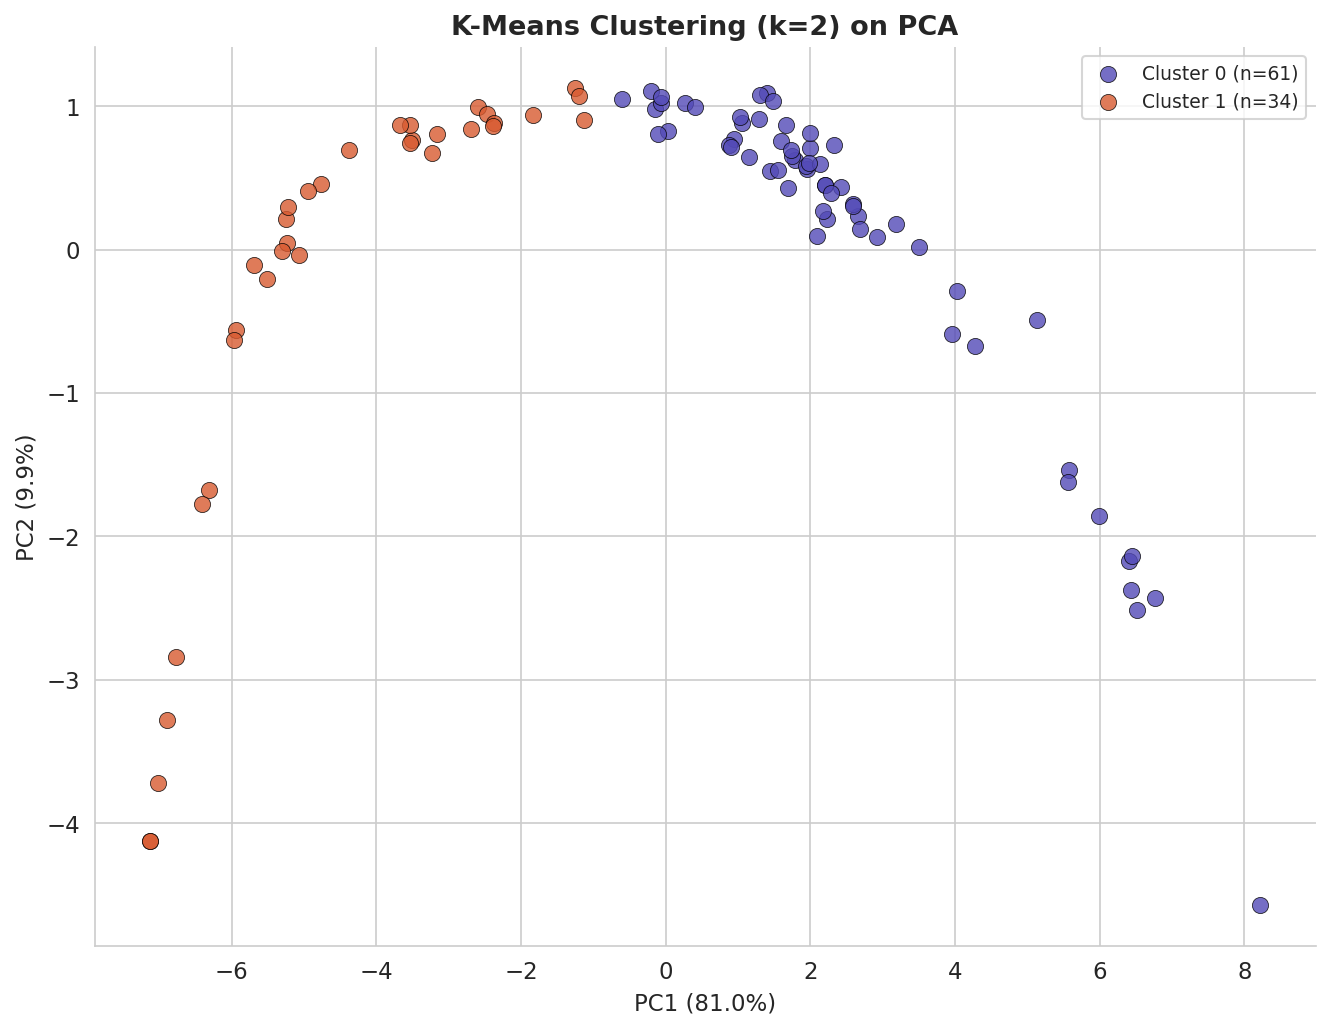

In [30]:
# === 5e. K-MEANS CLUSTERING ON PCA ===

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
clusters = km_best.fit_predict(X_scaled)
df['cluster'] = clusters

palette = ['#534AB7', '#D85A30', '#1D9E75', '#BA7517', '#D4537E'][:best_k]

fig, ax = plt.subplots(figsize=(9, 7))
for c in range(best_k):
    mask = clusters == c
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        label=f'Cluster {c} (n={mask.sum()})',
        color=palette[c],
        edgecolors='black', linewidth=0.4, s=60, alpha=0.8
    )
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title(f'K-Means Clustering (k={best_k}) on PCA')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/15_kmeans_pca.png', dpi=300, bbox_inches='tight')
plt.show()

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


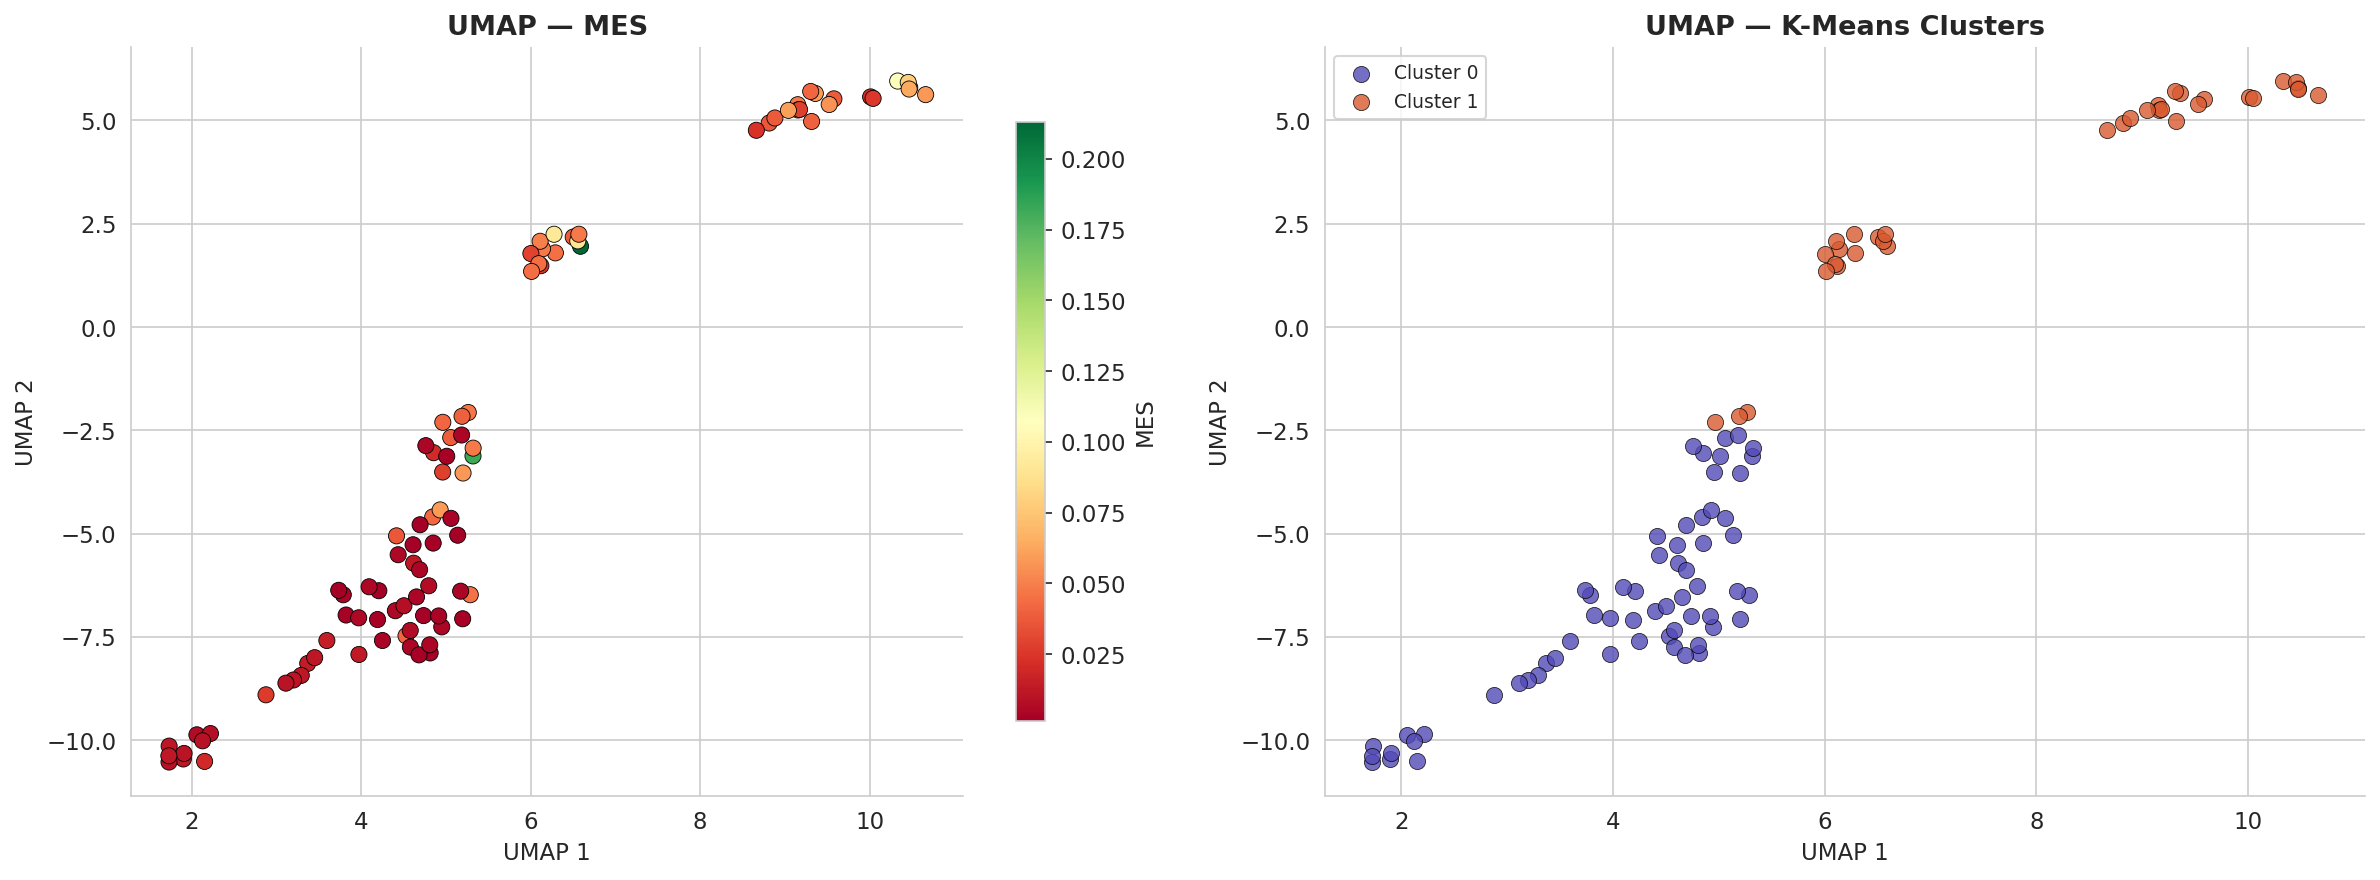

In [31]:
# === 5f. UMAP EMBEDDING ===

import umap

reducer = umap.UMAP(n_neighbors=min(15, len(df) - 1), random_state=42)
X_umap = reducer.fit_transform(X_scaled)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Colored by score
sc = ax1.scatter(X_umap[:, 0], X_umap[:, 1], c=df['MES'],
                 cmap='RdYlGn', edgecolors='black', linewidth=0.4, s=60)
plt.colorbar(sc, ax=ax1, label='MES', shrink=0.8)
ax1.set_xlabel('UMAP 1')
ax1.set_ylabel('UMAP 2')
ax1.set_title('UMAP — MES')
ax1.spines[['top', 'right']].set_visible(False)

# Colored by cluster
for c in range(best_k):
    mask = clusters == c
    ax2.scatter(X_umap[mask, 0], X_umap[mask, 1],
                label=f'Cluster {c}', color=palette[c],
                edgecolors='black', linewidth=0.4, s=60, alpha=0.8)
ax2.set_xlabel('UMAP 1')
ax2.set_ylabel('UMAP 2')
ax2.set_title('UMAP — K-Means Clusters')
ax2.legend(fontsize=9)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGDIR}/16_umap.png', dpi=300, bbox_inches='tight')
plt.show()

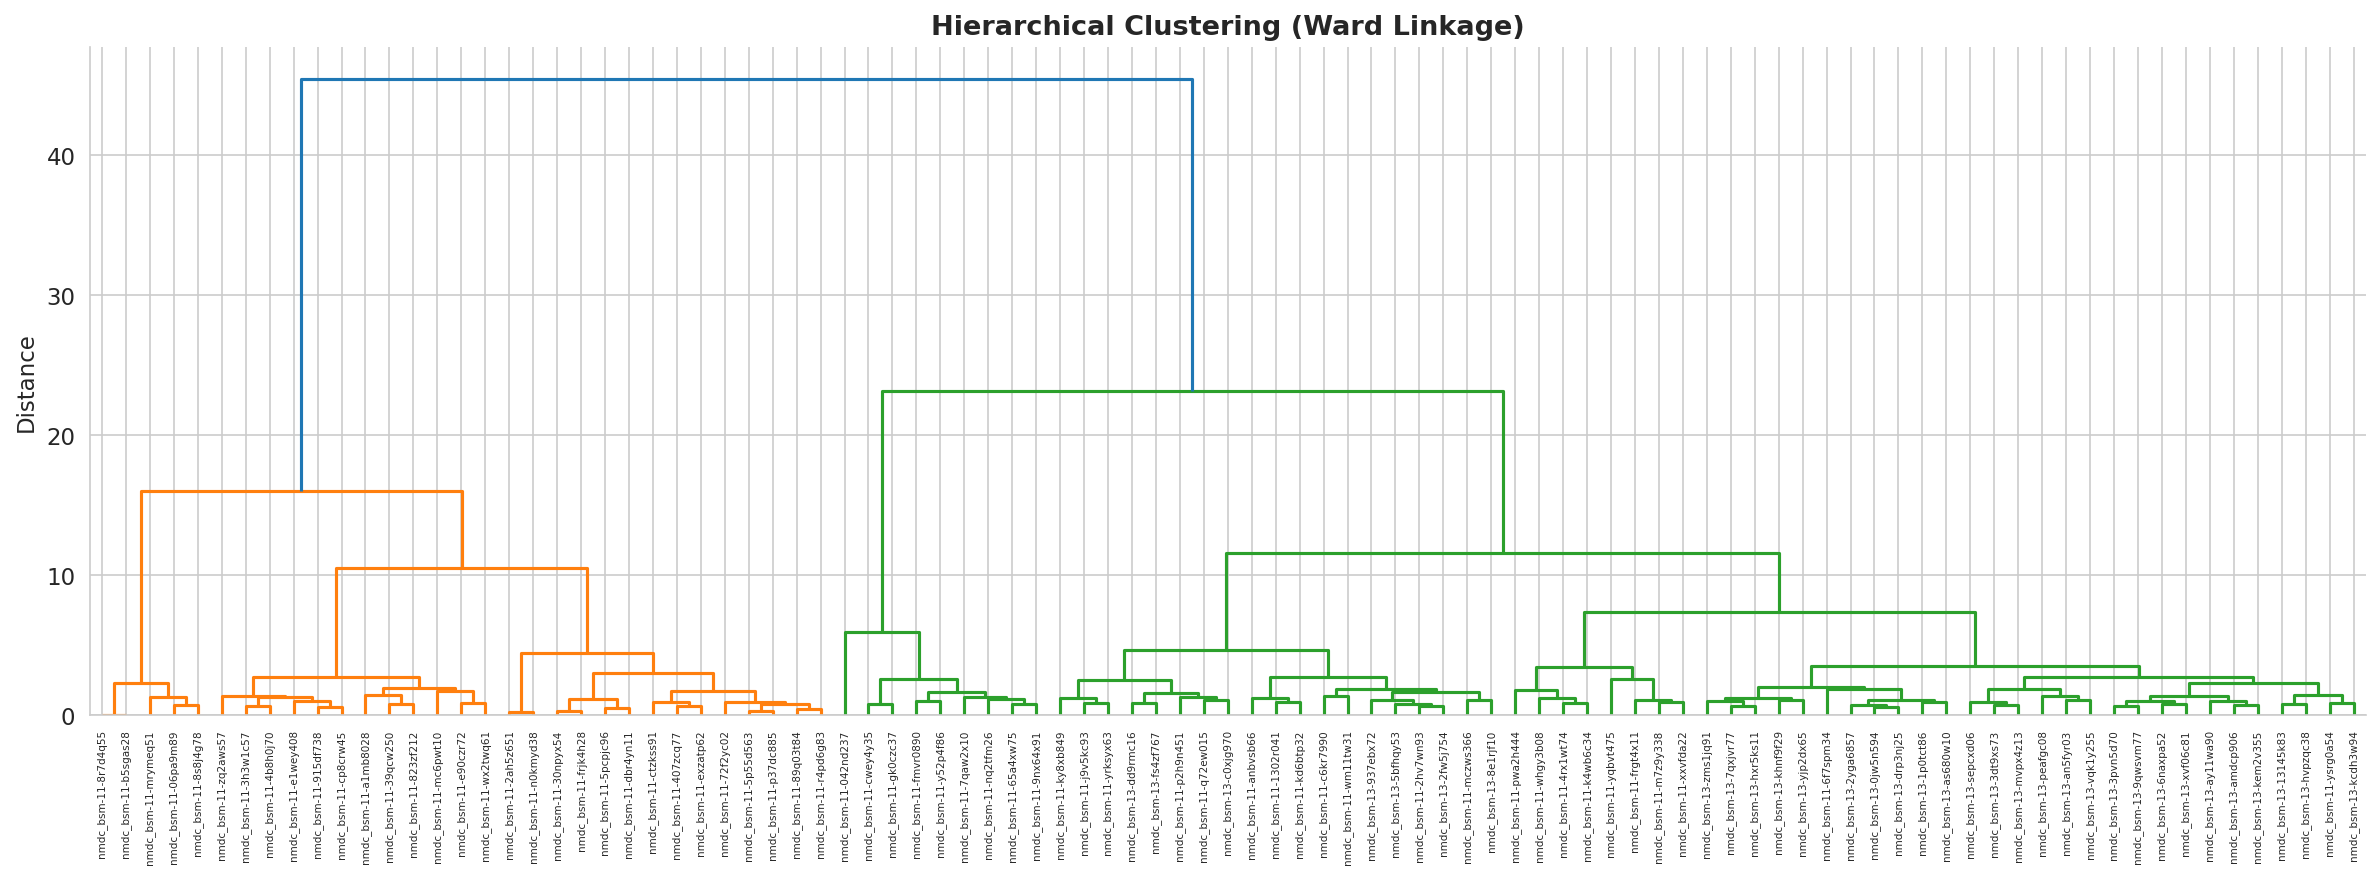

In [32]:
# === 5g. HIERARCHICAL CLUSTERING DENDROGRAM ===

from scipy.cluster.hierarchy import dendrogram, linkage

Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dn = dendrogram(
    Z, labels=df['biosample'].values,
    leaf_rotation=90, leaf_font_size=5, ax=ax,
    color_threshold=Z[-best_k + 1, 2] if best_k > 1 else None
)
ax.set_title('Hierarchical Clustering (Ward Linkage)')
ax.set_ylabel('Distance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/17_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 6. Cluster Profiling

In [33]:
# === 6a. CLUSTER PROFILING TABLE ===

profile = df.groupby('cluster')[feature_cols + ['MES']].agg(['mean', 'std'])
profile.columns = [f'{col}_{stat}' for col, stat in profile.columns]

# Build a clean summary
profile_clean = pd.DataFrame()
for feat in feature_cols + ['MES']:
    row = {}
    row['Feature'] = shorten_label(feat)
    for c in range(best_k):
        m = profile.loc[c, f'{feat}_mean']
        s = profile.loc[c, f'{feat}_std']
        row[f'Cluster {c}'] = f'{m:.3f} ± {s:.3f}'
    profile_clean = pd.concat([profile_clean, pd.DataFrame([row])], ignore_index=True)

display(profile_clean.style
    .set_caption('Cluster Profiling — Mean ± Std per Feature')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px'), ('font-size', '10px')]},
        {'selector': 'td', 'props': [('padding', '5px 12px'), ('font-size', '10px')]},
        {'selector': 'tr:last-child td', 'props': [('background-color', '#eafaf1'), ('font-weight', 'bold')]},
    ])
)

Feature,Cluster 0,Cluster 1
total_ec_count,83137.508 ± 88882.315,2196.824 ± 3008.189
unique_ec_count,2071.361 ± 343.114,544.147 ± 502.583
ec_level1_count,7.000 ± 0.000,6.029 ± 2.139
ec_level2_count,67.246 ± 1.090,44.000 ± 22.494
ec_level3_count,221.279 ± 8.029,112.029 ± 70.728
total_ko_count,150136.361 ± 170393.117,3597.088 ± 4875.445
unique_ko_count,5327.836 ± 1695.152,1079.588 ± 1043.425
benzoate_cov,0.540 ± 0.076,0.118 ± 0.129
benzene_cov,0.259 ± 0.080,0.060 ± 0.057
toluene_cov,0.270 ± 0.099,0.032 ± 0.034


In [34]:
# === 6b. MES BY CLUSTER — SUMMARY TABLE ===

cluster_summary = df.groupby('cluster').agg(
    n_samples=('biosample', 'count'),
    mean_score=('MES', 'mean'),
    std_score=('MES', 'std'),
    median_score=('MES', 'median'),
    min_score=('MES', 'min'),
    max_score=('MES', 'max'),
    pct_degraders=('MES_label', 'mean'),
).reset_index()
cluster_summary['pct_degraders'] = (cluster_summary['pct_degraders'] * 100).round(1)

display(cluster_summary.style
    .set_caption('MES by Cluster')
    .format({
        'mean_score': '{:.4f}', 'std_score': '{:.4f}',
        'median_score': '{:.4f}', 'min_score': '{:.4f}',
        'max_score': '{:.4f}', 'pct_degraders': '{:.1f}%',
    })
    .hide(axis='index')
    .background_gradient(subset=['mean_score'], cmap='RdYlGn', vmin=0, vmax=1)
    .background_gradient(subset=['pct_degraders'], cmap='RdYlGn', vmin=0, vmax=100)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

cluster,n_samples,mean_score,std_score,median_score,min_score,max_score,pct_degraders
0,61,0.0154,0.0262,0.0070,0.0013,0.1824,34.4%
1,34,0.0530,0.0347,0.0444,0.0217,0.2131,14.7%


In [35]:
# === 6c. KRUSKAL-WALLIS TEST ===

from scipy.stats import kruskal

groups = [df.loc[df['cluster'] == c, 'MES'].values for c in range(best_k)]

if all(len(g) > 1 for g in groups):
    stat, pval = kruskal(*groups)
    test_result = pd.DataFrame({
        'Test': ['Kruskal-Wallis H'],
        'Statistic': [f'{stat:.3f}'],
        'p-value': [f'{pval:.6f}'],
        'Significant (α=0.05)': ['Yes ✓' if pval < 0.05 else 'No'],
        'Interpretation': [
            'Clusters have SIGNIFICANTLY different MES'
            if pval < 0.05 else
            'No significant difference between clusters'
        ]
    })
    display(test_result.style
        .set_caption('Statistical Test — Cluster Differences')
        .hide(axis='index')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
            {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
            {'selector': 'td', 'props': [('padding', '6px 12px')]},
        ])
    )

Test,Statistic,p-value,Significant (α=0.05),Interpretation
Kruskal-Wallis H,44.576,0.000000,Yes ✓,Clusters have SIGNIFICANTLY different MES


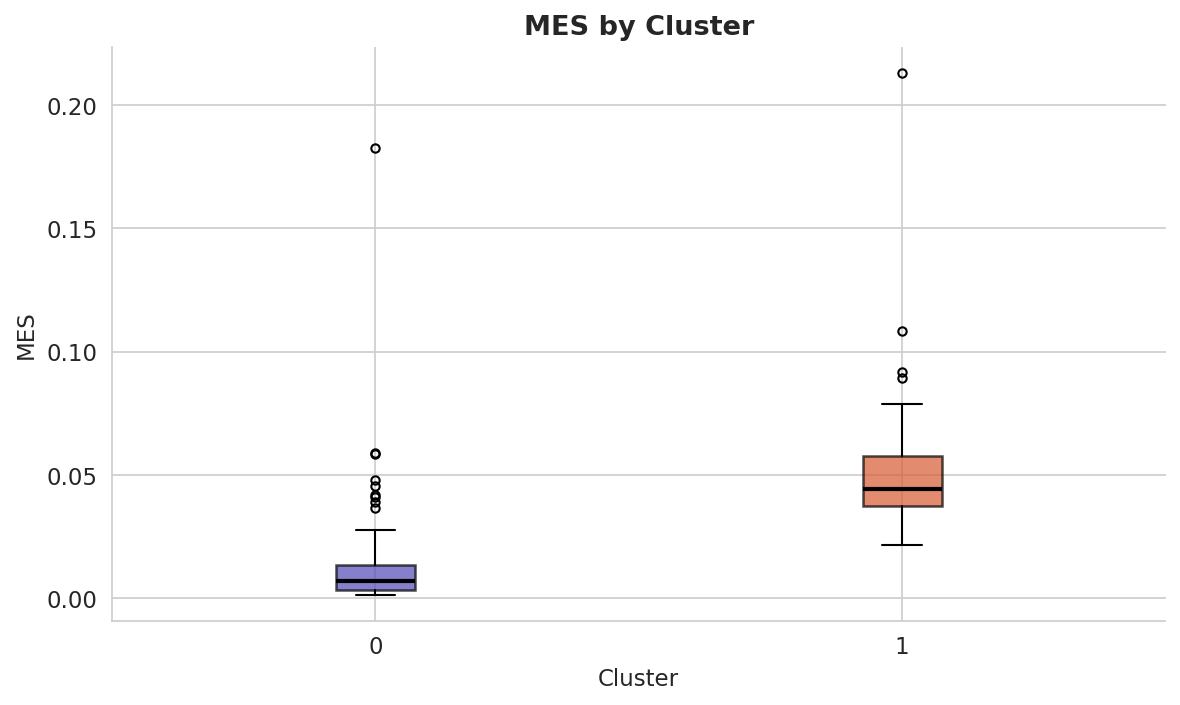

In [36]:
# === 6d. CLUSTER BOXPLOT ===

fig, ax = plt.subplots(figsize=(8, 5))
bp = df.boxplot(
    column='MES', by='cluster', ax=ax,
    patch_artist=True, return_type='dict',
    boxprops=dict(linewidth=1.2),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1),
    flierprops=dict(marker='o', markersize=4)
)
for i, patch in enumerate(bp['MES']['boxes']):
    patch.set_facecolor(palette[i % len(palette)])
    patch.set_alpha(0.7)
ax.set_xlabel('Cluster')
ax.set_ylabel('MES')
ax.set_title('MES by Cluster')
plt.suptitle('')  # remove auto title from boxplot
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/18_cluster_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

---
## 7. KO-Level Pattern Discovery

In [37]:
# === 7a. DIFFERENTIAL KO ANALYSIS ===

from ko_processing import build_ko_long_table
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests

# Build KO long table across all studies
studies = [
    d for d in os.listdir(KO_ROOT)
    if d.startswith('sty-') and os.path.isdir(os.path.join(KO_ROOT, d))
]

all_ko_long = []
for study in studies:
    try:
        ko_long = build_ko_long_table(os.path.join(KO_ROOT, study))
        all_ko_long.append(ko_long)
    except Exception as e:
        print(f'Skipping {study}: {e}')

ko_long = pd.concat(all_ko_long, ignore_index=True)

# Merge cluster info
ko_clustered = ko_long.merge(
    df[['biosample', 'cluster', 'MES']],
    on='biosample', how='inner'
)

ko_summary = pd.DataFrame({
    'Metric': [
        'KO annotations with cluster info',
        'Unique KOs',
        'Unique biosamples with KO+cluster',
    ],
    'Value': [
        f'{len(ko_clustered):,}',
        f'{ko_clustered["KO"].nunique():,}',
        f'{ko_clustered["biosample"].nunique():,}',
    ]
})

display(ko_summary.style
    .set_caption('KO Data Summary')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

Metric,Value
KO annotations with cluster info,"361,704"
Unique KOs,"13,713"
Unique biosamples with KO+cluster,95


In [38]:
# === 7b. FISHER EXACT TEST — HIGH vs LOW CLUSTER ===

cluster_means = df.groupby('cluster')['MES'].mean()
high_cluster = cluster_means.idxmax()
low_cluster = cluster_means.idxmin()

cluster_id_info = pd.DataFrame({
    'Role': ['High degradation cluster', 'Low degradation cluster'],
    'Cluster ID': [high_cluster, low_cluster],
    'Mean Score': [f'{cluster_means[high_cluster]:.3f}', f'{cluster_means[low_cluster]:.3f}'],
    'n Samples': [
        (df['cluster'] == high_cluster).sum(),
        (df['cluster'] == low_cluster).sum()
    ]
})

display(cluster_id_info.style
    .set_caption('Cluster Assignment for Differential Analysis')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

# Run Fisher test
high_samples = set(df[df['cluster'] == high_cluster]['biosample'])
low_samples = set(df[df['cluster'] == low_cluster]['biosample'])

ko_presence = ko_clustered.groupby(['biosample', 'KO']).size().unstack(fill_value=0)
ko_presence = (ko_presence > 0).astype(int)

results = []
for ko in ko_presence.columns:
    a = ko_presence.loc[ko_presence.index.isin(high_samples), ko].sum()
    b = len(high_samples) - a
    c = ko_presence.loc[ko_presence.index.isin(low_samples), ko].sum()
    d = len(low_samples) - c
    if a + c < 3:
        continue
    odds_ratio, pval = fisher_exact([[a, b], [c, d]])
    results.append({
        'KO': ko,
        'Prev (high)': a / len(high_samples) if high_samples else 0,
        'Prev (low)': c / len(low_samples) if low_samples else 0,
        'Odds Ratio': odds_ratio,
        'p-value': pval,
        'log2(OR)': np.log2(odds_ratio + 1e-9)
    })

diff_ko = pd.DataFrame(results)
diff_ko['FDR'] = multipletests(diff_ko['p-value'], method='fdr_bh')[1]
diff_ko = diff_ko.sort_values('log2(OR)', ascending=False)

sig_ko = diff_ko[diff_ko['FDR'] < 0.1]
print(f'Significant KOs (FDR < 0.1): {len(sig_ko):,} out of {len(diff_ko):,} tested')

Role,Cluster ID,Mean Score,n Samples
High degradation cluster,1,0.053,34
Low degradation cluster,0,0.015,61


Significant KOs (FDR < 0.1): 9,180 out of 11,371 tested


In [39]:
# === 7c. TOP KOs ENRICHED IN HIGH DEGRADATION ===

top_high = sig_ko.head(20).copy()
top_high_display = top_high[['KO', 'Prev (high)', 'Prev (low)', 'Odds Ratio', 'p-value', 'FDR']].copy()

display(top_high_display.style
    .set_caption('Top 20 KOs Enriched in HIGH Degradation Cluster')
    .format({
        'Prev (high)': '{:.3f}',
        'Prev (low)': '{:.3f}',
        'Odds Ratio': '{:.2f}',
        'p-value': '{:.2e}',
        'FDR': '{:.2e}',
    })
    .hide(axis='index')
    .background_gradient(subset=['Prev (high)'], cmap='Greens', vmin=0, vmax=1)
    .background_gradient(subset=['FDR'], cmap='YlOrRd_r', vmin=0, vmax=0.1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px'), ('color', '#1D9E75')]},
        {'selector': 'th', 'props': [('background-color', '#0F6E56'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('font-size', '11px')]},
    ])
)

KO,Prev (high),Prev (low),Odds Ratio,p-value,FDR
K08902,0.088,0.000,inf,4.32e-02,5.81e-02
K07539,0.147,0.344,0.33,5.43e-02,6.74e-02
K10085,0.265,0.525,0.33,1.78e-02,2.50e-02
K19268,0.118,0.295,0.32,7.45e-02,9.24e-02
K17995,0.118,0.295,0.32,7.45e-02,9.24e-02
K09974,0.235,0.492,0.32,1.70e-02,2.39e-02
K15530,0.118,0.311,0.29,4.55e-02,5.90e-02
K09858,0.118,0.311,0.29,4.55e-02,5.90e-02
K04516,0.176,0.426,0.29,1.43e-02,2.02e-02
K01914,0.118,0.328,0.27,2.76e-02,3.73e-02


In [40]:
# === 7d. TOP KOs ENRICHED IN LOW DEGRADATION ===

top_low = sig_ko.tail(20).copy()
top_low_display = top_low[['KO', 'Prev (high)', 'Prev (low)', 'Odds Ratio', 'p-value', 'FDR']].copy()

display(top_low_display.style
    .set_caption('Top 20 KOs Enriched in LOW Degradation Cluster')
    .format({
        'Prev (high)': '{:.3f}',
        'Prev (low)': '{:.3f}',
        'Odds Ratio': '{:.2f}',
        'p-value': '{:.2e}',
        'FDR': '{:.2e}',
    })
    .hide(axis='index')
    .background_gradient(subset=['Prev (low)'], cmap='Oranges', vmin=0, vmax=1)
    .background_gradient(subset=['FDR'], cmap='YlOrRd_r', vmin=0, vmax=0.1)
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px'), ('color', '#D85A30')]},
        {'selector': 'th', 'props': [('background-color', '#993C1D'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '5px 10px'), ('font-size', '11px')]},
    ])
)

KO,Prev (high),Prev (low),Odds Ratio,p-value,FDR
K10807,0.000,0.262,0.00,4.33e-04,8.14e-04
K10808,0.000,0.262,0.00,4.33e-04,8.14e-04
K10752,0.000,0.230,0.00,1.66e-03,2.80e-03
K10753,0.000,0.180,0.00,6.69e-03,9.90e-03
K10754,0.000,0.197,0.00,3.66e-03,5.68e-03
K10755,0.000,0.246,0.00,8.34e-04,1.49e-03
K10756,0.000,0.230,0.00,1.66e-03,2.80e-03
K10771,0.000,0.148,0.00,2.41e-02,3.25e-02
K10773,0.412,1.000,0.00,8.13e-12,3.73e-11
K10775,0.000,0.410,0.00,1.74e-06,4.35e-06


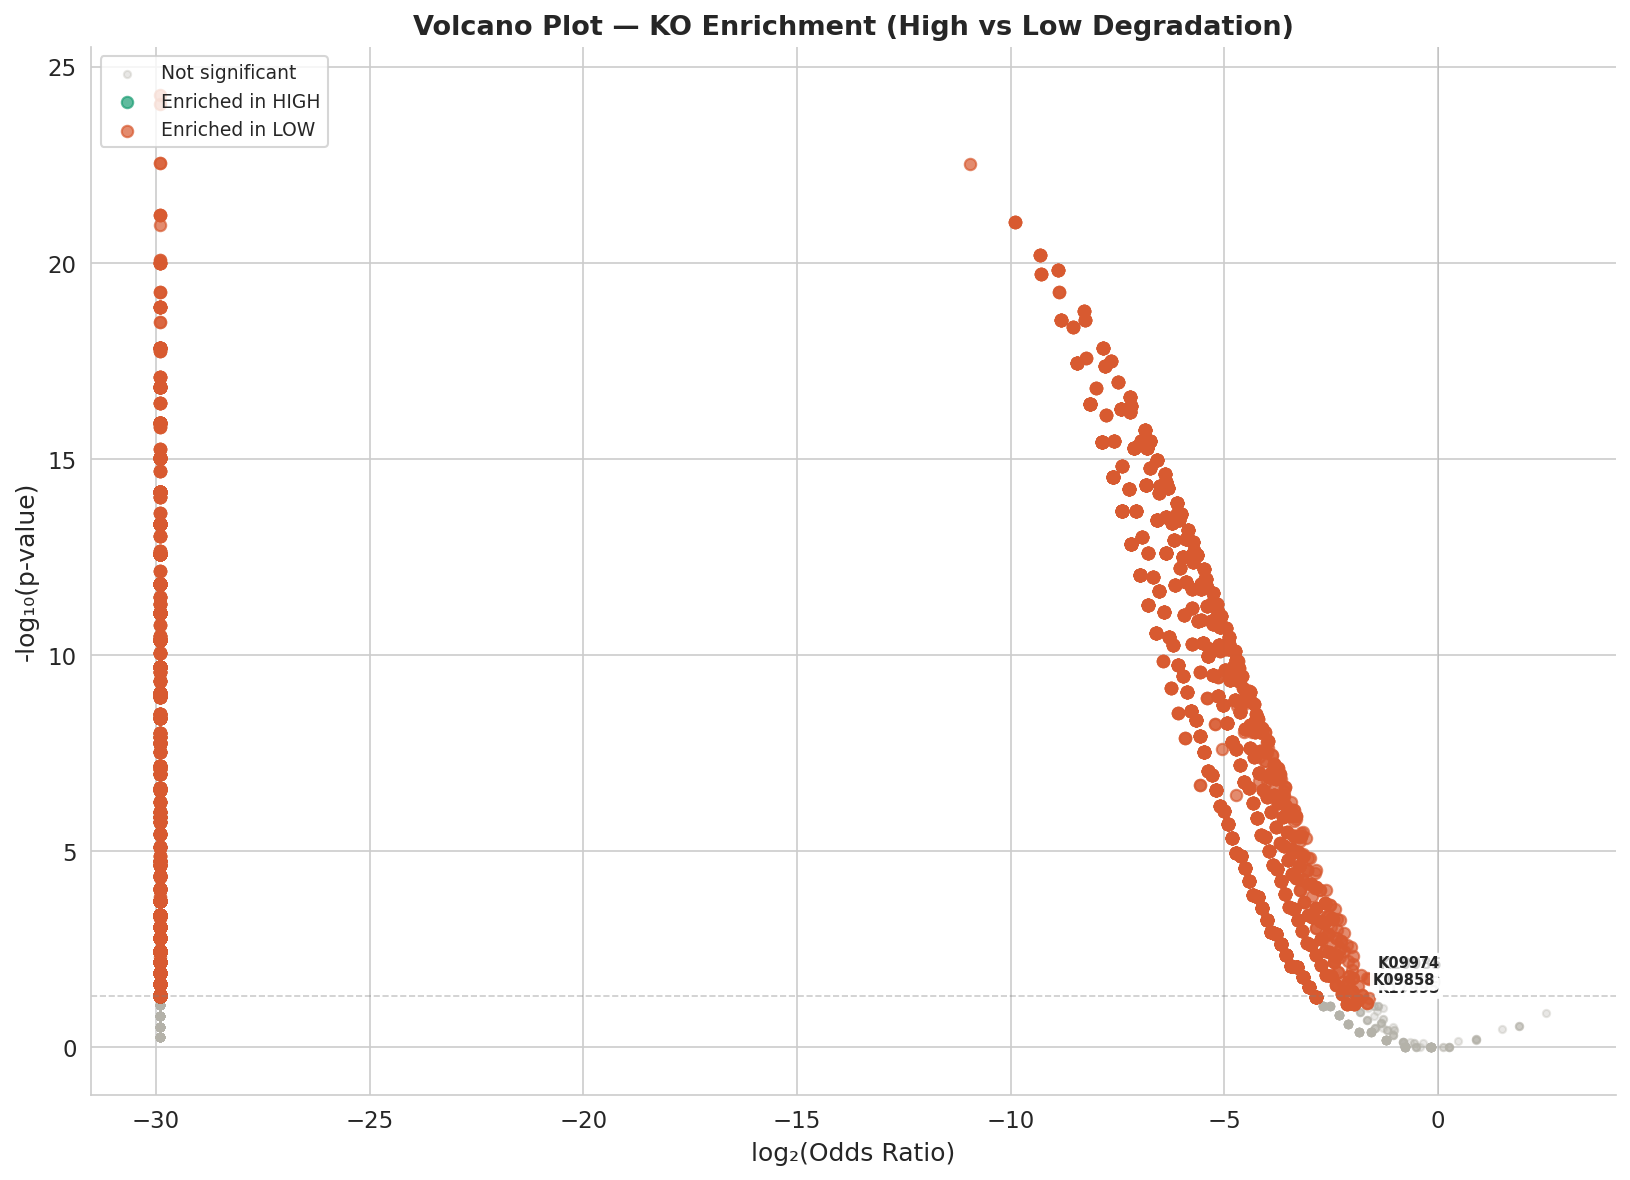

In [41]:
# === 7e. VOLCANO PLOT ===

fig, ax = plt.subplots(figsize=(11, 8))

sig_mask = diff_ko['FDR'] < 0.1
enriched_high = sig_mask & (diff_ko['log2(OR)'] > 0)
enriched_low = sig_mask & (diff_ko['log2(OR)'] < 0)
ns = ~sig_mask

ax.scatter(
    diff_ko.loc[ns, 'log2(OR)'],
    -np.log10(diff_ko.loc[ns, 'p-value']),
    c='#B4B2A9', alpha=0.3, s=12, label='Not significant', zorder=1
)
ax.scatter(
    diff_ko.loc[enriched_high, 'log2(OR)'],
    -np.log10(diff_ko.loc[enriched_high, 'p-value']),
    c='#1D9E75', alpha=0.7, s=30, label='Enriched in HIGH', zorder=2
)
ax.scatter(
    diff_ko.loc[enriched_low, 'log2(OR)'],
    -np.log10(diff_ko.loc[enriched_low, 'p-value']),
    c='#D85A30', alpha=0.7, s=30, label='Enriched in LOW', zorder=2
)

ax.axhline(-np.log10(0.05), linestyle='--', color='gray', alpha=0.4, linewidth=0.8)
ax.axvline(0, linestyle='-', color='gray', alpha=0.2, linewidth=0.5)

# Annotate top hits
top_hits = sig_ko.head(8)
for _, row in top_hits.iterrows():
    ax.annotate(
        row['KO'],
        (row['log2(OR)'], -np.log10(row['p-value'])),
        fontsize=7, fontweight='bold',
        xytext=(5, 5), textcoords='offset points',
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )

ax.set_xlabel('log₂(Odds Ratio)', fontsize=12)
ax.set_ylabel('-log₁₀(p-value)', fontsize=12)
ax.set_title('Volcano Plot — KO Enrichment (High vs Low Degradation)', fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIGDIR}/19_volcano_ko.png', dpi=300, bbox_inches='tight')
plt.show()

In [42]:
# === 7f. SUMMARY STATISTICS TABLE ===

final_summary = pd.DataFrame({
    'Metric': [
        'Total KOs tested',
        'Significant KOs (FDR < 0.1)',
        'Enriched in HIGH degradation',
        'Enriched in LOW degradation',
        'High cluster mean score',
        'Low cluster mean score',
    ],
    'Value': [
        f'{len(diff_ko):,}',
        f'{len(sig_ko):,}',
        f'{(sig_ko["log2(OR)"] > 0).sum():,}',
        f'{(sig_ko["log2(OR)"] < 0).sum():,}',
        f'{cluster_means[high_cluster]:.4f}',
        f'{cluster_means[low_cluster]:.4f}',
    ]
})

display(final_summary.style
    .set_caption('KO Differential Analysis — Summary')
    .hide(axis='index')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('margin-bottom', '8px')]},
        {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('padding', '8px')]},
        {'selector': 'td', 'props': [('padding', '6px 12px')]},
    ])
)

print('\nAll figures saved to:', FIGDIR)

Metric,Value
Total KOs tested,"11,371"
Significant KOs (FDR < 0.1),"9,180"
Enriched in HIGH degradation,1
Enriched in LOW degradation,"9,179"
High cluster mean score,0.0530
Low cluster mean score,0.0154



All figures saved to: /content/ML-BIO-TECH/model/figures
